# Laboratorio 4 - Milton Beltrán

## 0. Preparación del corpus

Este notebook es **autocontenido**, igual que los de los laboratorios anteriores: repite aquí la
carga del corpus, el pipeline de normalización, las particiones y las representaciones vectoriales
del Laboratorio #3, en lugar de importarlos desde aquel notebook.

El enunciado exige reutilizar **exactamente** las mismas particiones y los mismos vectorizadores
ajustados en el Lab #3, para que la comparación entre Naive Bayes y regresión logística sea justa.
Como no se están importando sino **reconstruyendo**, eso solo vale si el resultado es idéntico, y lo
es porque todo el pipeline es determinista: `random_state=42` fijo, vectorizadores sin parámetros y
el mismo corpus de partida. Al final de cada celda crítica hay un `assert` que lo comprueba en vez de
darlo por hecho.

In [1]:
# --- 0.1 Librerías ---

# --- Librerías estándar de Python ---
from collections import Counter
import time

# --- Manejo de datos y gráficos ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# --- Nuevo en el Lab #4 ---
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier      # línea base de clase mayoritaria (Sección 7)
from sklearn.preprocessing import normalize    # diagnóstico de escala (Sección 2)
from scipy.stats import binomtest              # test de McNemar (Sección 4)

In [2]:
# --- 0.2 Carga del corpus y limpieza de filas inservibles ---
# Misma cadena de limpieza del Lab #3: 1217 -> 1142 -> 1140 -> 1134 documentos.

df = pd.read_csv("df_total.csv")

# i. Filas completamente duplicadas. Se eliminan antes de normalizar.
df_prep = df.drop_duplicates().reset_index(drop=True)
print("Documentos originales:", len(df))
print("Documentos tras quitar duplicados:", len(df_prep))

# ii. Documentos sin texto: no aportan nada al vectorizador.
vacios = df_prep["news"].str.strip() == ""
print("Documentos con texto vacío:", int(vacios.sum()), "->", df_prep.loc[vacios, "Type"].tolist())
df_prep = df_prep[~vacios].reset_index(drop=True)

# iii. Noticias con el mismo texto y etiquetas CONTRADICTORIAS (3 pares).
#      Se eliminan las dos copias de cada par (keep=False): sin criterio objetivo para elegir
#      la etiqueta correcta, dejar una sería inventarse la anotación. Si sobrevivieran, habría
#      fuga entre entrenamiento y prueba y un techo de exactitud imposible de alcanzar.
contradictorios = df_prep.duplicated("news", keep=False)
print("Filas con texto repetido y etiqueta contradictoria:", int(contradictorios.sum()))
df_prep = df_prep[~contradictorios].reset_index(drop=True)

print()
print("Documentos de trabajo (definitivo):", len(df_prep))
print("Categorías:", df_prep["Type"].nunique())
print()
print(df_prep["Type"].value_counts().to_string())

# El corpus del Lab #3 tenía 1,134 documentos: si aquí saliera otro número, todo lo que sigue
# dejaría de ser comparable con aquel laboratorio.
assert len(df_prep) == 1134, f"Se esperaban 1,134 documentos y hay {len(df_prep)}"

Documentos originales: 1217
Documentos tras quitar duplicados: 1142
Documentos con texto vacío: 2 -> ['Sostenibilidad', 'Macroeconomia']
Filas con texto repetido y etiqueta contradictoria: 6

Documentos de trabajo (definitivo): 1134
Categorías: 7

Type
Macroeconomia     319
Alianzas          244
Innovacion        152
Regulaciones      141
Otra              128
Sostenibilidad    124
Reputacion         26


In [3]:
# --- 0.3 Pipeline de normalización (heredado de los Laboratorios #1 y #2) ---
# tokenización -> minúsculas -> sin puntuación -> sin stopwords -> stemming

stop_es = set(stopwords.words("spanish"))
stemmer = SnowballStemmer("spanish")

# i. Tokenización
df_prep["tokens"] = df_prep["news"].apply(
    lambda t: word_tokenize(t, language="spanish")
)

# ii. Minúsculas
df_prep["tokens"] = df_prep["tokens"].apply(
    lambda lista: [tok.lower() for tok in lista]
)

# iii. Quitar puntuación
df_prep["tokens"] = df_prep["tokens"].apply(
    lambda lista: [tok for tok in lista if tok.isalpha()]
)

# iv. Quitar stopwords
df_prep["tokens"] = df_prep["tokens"].apply(
    lambda lista: [tok for tok in lista if tok not in stop_es]
)

# v. Stemming ("lematización"): tokens_norm guarda las palabras legibles, tokens_stem las raíces.
df_prep["tokens_norm"] = df_prep["tokens"]
df_prep["tokens_stem"] = df_prep["tokens_norm"].apply(
    lambda lista: [stemmer.stem(tok) for tok in lista]
)

# Los vectorizadores de scikit-learn reciben strings, no listas de tokens.
df_prep["texto_norm"] = df_prep["tokens_stem"].apply(lambda lista: " ".join(lista))


def contar(col_de_listas):
    """Aplana una columna de listas de tokens y devuelve (tokens, tipos)."""
    todos = [tok for lista in col_de_listas for tok in lista]
    return len(todos), len(set(todos))


tok, tip = contar(df_prep["tokens_stem"])
print(f"Corpus normalizado: documentos={len(df_prep):,}  tokens={tok:,}  tipos={tip:,}")
print("Columnas del DataFrame:", list(df_prep.columns))

# Mismas cifras que el Lab #3: el pipeline no cambió.
assert (tok, tip) == (298753, 13093), f"El pipeline cambió: tokens={tok:,}, tipos={tip:,}"

Corpus normalizado: documentos=1,134  tokens=298,753  tipos=13,093
Columnas del DataFrame: ['url', 'news', 'Type', 'tokens', 'tokens_norm', 'tokens_stem', 'texto_norm']


In [4]:
# --- 0.4 Particiones 70 / 15 / 15 estratificadas (las MISMAS del Lab #3) ---
# train_test_split solo parte en DOS, así que se llama dos veces:
#   1) corpus -> train (70 %) + temp (30 %)
#   2) temp   -> validación (15 %) + prueba (15 %)   <- test_size=0.5 sobre el 30 %, no 0.15
# Se parten los ÍNDICES del DataFrame, no las columnas sueltas, para poder recuperar el texto
# original de cualquier documento mal clasificado en el análisis de errores (Sección 6).

RANDOM_STATE = 42

y_total = df_prep["Type"]

idx_train, idx_temp = train_test_split(
    df_prep.index,
    test_size=0.30,
    stratify=y_total,
    random_state=RANDOM_STATE,
)

idx_val, idx_test = train_test_split(
    idx_temp,
    test_size=0.50,                 # la mitad del 30 % -> 15 % y 15 %
    stratify=y_total.loc[idx_temp],
    random_state=RANDOM_STATE,
)

X_train_txt, y_train = df_prep.loc[idx_train, "texto_norm"], y_total.loc[idx_train]
X_val_txt,   y_val   = df_prep.loc[idx_val,   "texto_norm"], y_total.loc[idx_val]
X_test_txt,  y_test  = df_prep.loc[idx_test,  "texto_norm"], y_total.loc[idx_test]

total = len(df_prep)
for nombre, conj in [("Entrenamiento", y_train), ("Validación", y_val), ("Prueba", y_test)]:
    print(f"{nombre:<15}{len(conj):>5} documentos  ({len(conj)/total:.1%})")
print(f"{'Total':<15}{len(y_train) + len(y_val) + len(y_test):>5} documentos")

# Conjuntos disjuntos que cubren el corpus completo.
assert len(set(idx_train) & set(idx_val)) == 0
assert len(set(idx_train) & set(idx_test)) == 0
assert len(set(idx_val) & set(idx_test)) == 0
assert len(idx_train) + len(idx_val) + len(idx_test) == total

# LA comprobación del laboratorio: 793 / 170 / 171 son exactamente los tamaños del Lab #3.
# Si esto fallara, cualquier comparación con el Naive Bayes de aquel laboratorio sería inválida,
# porque la diferencia de desempeño podría venir de las particiones y no del algoritmo.
assert (len(idx_train), len(idx_val), len(idx_test)) == (793, 170, 171)
print("\nParticiones idénticas a las del Laboratorio #3.")

Entrenamiento    793 documentos  (69.9%)
Validación       170 documentos  (15.0%)
Prueba           171 documentos  (15.1%)
Total           1134 documentos

Particiones idénticas a las del Laboratorio #3.


In [5]:
# --- 0.5 Representaciones vectoriales (los MISMOS vectorizadores del Lab #3) ---
# Ambos se ajustan SOLO con entrenamiento: fit_transform en train, transform en validación y
# prueba. En TF-IDF la restricción es doble, porque el fit aprende el vocabulario y además los
# IDF; calcularlos sobre el corpus completo metería en el peso de cada palabra información sobre
# en cuántos documentos de prueba aparece.

bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train_txt)
X_val_bow   = bow_vectorizer.transform(X_val_txt)
X_test_bow  = bow_vectorizer.transform(X_test_txt)

tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_txt)
X_val_tfidf   = tfidf_vectorizer.transform(X_val_txt)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_txt)

vocab_bow = bow_vectorizer.get_feature_names_out()

print("Matriz BoW de entrenamiento:   ", X_train_bow.shape)
print("Matriz TF-IDF de entrenamiento:", X_train_tfidf.shape)
print("Vocabulario aprendido en entrenamiento:", f"{len(vocab_bow):,} términos")
print("¿Mismo vocabulario en las dos representaciones?",
      list(vocab_bow) == list(tfidf_vectorizer.get_feature_names_out()))
print()

# Misma forma, contenido distinto: BoW guarda conteos enteros sin cota, TF-IDF pesos reales
# normalizados a norma L2 = 1. Esa diferencia de escala es la que explicará buena parte de los
# resultados de la Sección 2.
fila_bow, fila_tfidf = X_train_bow[0], X_train_tfidf[0]
print(f"Documento de entrenamiento 0 — términos distintos: {fila_bow.nnz}")
print(f"  BoW  : enteros, máximo = {int(fila_bow.data.max())}, suma = {int(fila_bow.sum())}")
print(f"  TFIDF: reales,  máximo = {fila_tfidf.data.max():.4f}, "
      f"norma L2 = {np.sqrt((fila_tfidf.data ** 2).sum()):.4f}")

# Mismo vocabulario que en el Lab #3: los vectorizadores son los mismos, no unos equivalentes.
assert len(vocab_bow) == 10968, f"El vocabulario cambió: {len(vocab_bow):,} términos"
print("\nVectorizadores idénticos a los del Laboratorio #3.")

Matriz BoW de entrenamiento:    (793, 10968)
Matriz TF-IDF de entrenamiento: (793, 10968)
Vocabulario aprendido en entrenamiento: 10,968 términos
¿Mismo vocabulario en las dos representaciones? True



Documento de entrenamiento 0 — términos distintos: 74
  BoW  : enteros, máximo = 3, suma = 93
  TFIDF: reales,  máximo = 0.2840, norma L2 = 1.0000

Vectorizadores idénticos a los del Laboratorio #3.


In [6]:
# --- 0.6 Naive Bayes del Laboratorio #3 (línea de comparación) ---
# El enunciado pide tener disponible el clasificador del laboratorio anterior. Se reentrena aquí
# en vez de copiar sus números, para que los tiempos de la Sección 4 se midan en la misma máquina.

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

for nombre, modelo, X in [("BoW", nb_bow, X_val_bow), ("TF-IDF", nb_tfidf, X_val_tfidf)]:
    pred = modelo.predict(X)
    print(f"Naive Bayes {nombre:<7} validación -> "
          f"accuracy {accuracy_score(y_val, pred):.4f} | "
          f"F1 macro {f1_score(y_val, pred, average='macro'):.4f}")

# Cifras del Lab #3 que este notebook debe reproducir: BoW 0.8000 / 0.7324, TF-IDF 0.5471 / 0.3602.
assert round(accuracy_score(y_val, nb_bow.predict(X_val_bow)), 4) == 0.8000
assert round(accuracy_score(y_val, nb_tfidf.predict(X_val_tfidf)), 4) == 0.5471
print("\nNaive Bayes reproduce exactamente los resultados del Laboratorio #3.")

Naive Bayes BoW     validación -> accuracy 0.8000 | F1 macro 0.7324
Naive Bayes TF-IDF  validación -> accuracy 0.5471 | F1 macro 0.3602

Naive Bayes reproduce exactamente los resultados del Laboratorio #3.


## 1. Construcción del clasificador de regresión logística

Se entrenan dos clasificadores de regresión logística sobre el mismo problema del Lab #3: uno con
la matriz de bolsa de palabras y otro con la matriz TF-IDF, ambas ya construidas en la Sección 0 a
partir del conjunto de entrenamiento únicamente.

A diferencia de Naive Bayes, que estima cada `P(wᵢ|c)` contando de forma aislada, la regresión
logística **aprende todos sus pesos a la vez**, optimizando directamente la separación entre las
siete categorías. Esta sección construye los modelos, mira qué forma tiene lo que aprendieron y
verifica paso a paso cómo se convierte un puntaje `z = w·x + b` en una probabilidad y luego en una
predicción de clase.

In [7]:
# --- 1.1 Entrenamiento de los dos modelos ---
# Se dejan los valores por defecto: solver='lbfgs', penalty='l2', C=1.0. El efecto de C se estudia
# en la Sección 5. random_state fijo por reproducibilidad.

lr_bow = LogisticRegression(random_state=RANDOM_STATE)
lr_bow.fit(X_train_bow, y_train)

lr_tfidf = LogisticRegression(random_state=RANDOM_STATE)
lr_tfidf.fit(X_train_tfidf, y_train)

# n_iter_ dice cuántas iteraciones necesitó el optimizador. Si llegara al límite (max_iter=100 por
# defecto) scikit-learn emitiría un ConvergenceWarning y los pesos no serían el óptimo, sino donde
# se quedó el optimizador: conviene comprobarlo en vez de suponerlo.
for nombre, modelo in [("BoW", lr_bow), ("TF-IDF", lr_tfidf)]:
    print(f"Regresión logística {nombre:<7} -> iteraciones {int(modelo.n_iter_[0]):>3} "
          f"de un máximo de {modelo.max_iter}  | convergió: {int(modelo.n_iter_[0]) < modelo.max_iter}")

print()
print("Ambos convergen dentro del límite por defecto, pero no cuesta lo mismo:")
print(f"  BoW necesita {lr_bow.n_iter_[0] / lr_tfidf.n_iter_[0]:.1f}× más iteraciones que TF-IDF.")

Regresión logística BoW     -> iteraciones  55 de un máximo de 100  | convergió: True
Regresión logística TF-IDF  -> iteraciones  33 de un máximo de 100  | convergió: True

Ambos convergen dentro del límite por defecto, pero no cuesta lo mismo:
  BoW necesita 1.7× más iteraciones que TF-IDF.


In [8]:
# --- 1.2 Qué aprendió el modelo, y qué forma tiene ---
# Con 7 categorías el modelo NO aprende un vector de pesos, sino uno por categoría.

print("coef_     ", lr_bow.coef_.shape, "-> (categorías, términos del vocabulario)")
print("intercept_", lr_bow.intercept_.shape, "-> un sesgo b por categoría")
print("classes_  ", list(lr_bow.classes_))
print()

# Naive Bayes guarda una matriz de la MISMA forma... pero lo que hay en cada celda es distinto.
print("Comparación con el Naive Bayes del Lab #3:")
print(f"  nb_bow.feature_log_prob_ {nb_bow.feature_log_prob_.shape} -> log P(w|c), estimado contando")
print(f"  lr_bow.coef_             {lr_bow.coef_.shape} -> pesos w, ajustados por optimización")
print()

# Diferencia clave: log P(w|c) es siempre negativo (es un logaritmo de probabilidad) y cada fila
# suma 1 al exponenciarla. Los pesos de la regresión logística no son probabilidades: pueden ser
# negativos, y un peso negativo es evidencia EN CONTRA de la categoría, algo que Naive Bayes no
# puede expresar.
print(f"log P(w|c) de Naive Bayes: mínimo {nb_bow.feature_log_prob_.min():.3f}, "
      f"máximo {nb_bow.feature_log_prob_.max():.3f}  (todos negativos)")
print(f"pesos de regresión logística: mínimo {lr_bow.coef_.min():.3f}, "
      f"máximo {lr_bow.coef_.max():.3f}")
print(f"  pesos positivos: {(lr_bow.coef_ > 0).sum():,} | "
      f"negativos: {(lr_bow.coef_ < 0).sum():,} | "
      f"exactamente cero: {(lr_bow.coef_ == 0).sum():,}")

coef_      (7, 10968) -> (categorías, términos del vocabulario)
intercept_ (7,) -> un sesgo b por categoría
classes_   ['Alianzas', 'Innovacion', 'Macroeconomia', 'Otra', 'Regulaciones', 'Reputacion', 'Sostenibilidad']

Comparación con el Naive Bayes del Lab #3:
  nb_bow.feature_log_prob_ (7, 10968) -> log P(w|c), estimado contando
  lr_bow.coef_             (7, 10968) -> pesos w, ajustados por optimización

log P(w|c) de Naive Bayes: mínimo -11.185, máximo -4.240  (todos negativos)
pesos de regresión logística: mínimo -0.824, máximo 1.013
  pesos positivos: 31,002 | negativos: 45,774 | exactamente cero: 0


In [9]:
# --- 1.3 De z a probabilidad y de probabilidad a clase, calculado a mano ---
# Se toma un documento de validación y se rehace el camino completo sin usar predict_proba,
# para comprobar que se entiende qué hace el modelo por dentro.

doc = 0
fila = X_val_bow[doc]

# i. Los siete puntajes z = w·x + b, uno por categoría. Son números sin escala: no son
#    probabilidades ni nada interpretable todavía.
z = np.asarray(fila @ lr_bow.coef_.T + lr_bow.intercept_).ravel()

# ii. Softmax: exponenciar y normalizar para que los siete valores sumen 1. Restar el máximo antes
#     de exponenciar no cambia el resultado y evita el desbordamiento de np.exp (la misma
#     protección usada en la implementación propia de Naive Bayes del Lab #3).
exp_z = np.exp(z - z.max())
probs = exp_z / exp_z.sum()

# iii. La predicción es simplemente la categoría con la probabilidad más alta.
prediccion = lr_bow.classes_[probs.argmax()]

tabla = pd.DataFrame({"z = w·x + b": z, "softmax(z)": probs}, index=lr_bow.classes_)
print(f"Documento {doc} de validación — categoría real: {y_val.iloc[doc]}")
print(tabla.sort_values("softmax(z)", ascending=False).to_string(
    formatters={"z = w·x + b": "{:.3f}".format, "softmax(z)": "{:.4f}".format}))
print(f"\nSuma de las siete probabilidades: {probs.sum():.4f}")
print(f"Predicción (argmax): {prediccion}  |  lr_bow.predict(): {lr_bow.predict(fila)[0]}")
print()

# ¿Coincide el cálculo manual con scikit-learn? Esta comprobación es la que demuestra que el
# modelo es MULTINOMIAL (softmax sobre las 7 clases) y no one-vs-rest.
print("softmax manual == predict_proba:",
      np.allclose(probs, lr_bow.predict_proba(fila).ravel()))

# Si el modelo fuese one-vs-rest, cada z pasaría por la sigmoide σ(z) = 1/(1+e^-z) por separado y
# las siete se normalizarían después. Da otros números: es la prueba de que NO es lo que ocurre.
sigmoides = 1 / (1 + np.exp(-z))
sigmoides_norm = sigmoides / sigmoides.sum()
print("sigmoide normalizada (one-vs-rest) == predict_proba:",
      np.allclose(sigmoides_norm, lr_bow.predict_proba(fila).ravel()))
print()
print("Probabilidad de la categoría ganadora:")
print(f"  softmax        : {probs.max():.4f}")
print(f"  one-vs-rest    : {sigmoides_norm.max():.4f}   (no es lo que usa el modelo)")

Documento 0 de validación — categoría real: Sostenibilidad
               z = w·x + b softmax(z)
Sostenibilidad       7.251     0.9953
Regulaciones         1.338     0.0027
Alianzas             0.593     0.0013
Otra                -0.419     0.0005
Macroeconomia       -1.033     0.0003
Reputacion          -3.523     0.0000
Innovacion          -4.207     0.0000

Suma de las siete probabilidades: 1.0000
Predicción (argmax): Sostenibilidad  |  lr_bow.predict(): Sostenibilidad

softmax manual == predict_proba: True
sigmoide normalizada (one-vs-rest) == predict_proba: False

Probabilidad de la categoría ganadora:
  softmax        : 0.9953
  one-vs-rest    : 0.3185   (no es lo que usa el modelo)


### 1.4 Resultados y discusión

#### ¿Qué representan `z = w·x + b` y la función sigmoide σ(z) = 1/(1+e⁻ᶻ)?

**`x`** es el documento ya vectorizado: una fila de 10,968 números, casi todos cero, donde cada
posición es un término del vocabulario aprendido en entrenamiento. **`w`** es el vector de pesos
que el modelo aprendió para *una* categoría, con un peso por término, y **`b`** es su sesgo, que
recoge lo que el modelo cree sobre esa categoría antes de leer el documento.

El producto punto `w·x` suma el peso de cada término tantas veces como aparece en el documento.
**`z` es un puntaje sin escala**: en el ejemplo de la celda 1.3 va de −4.2 a 7.3. Un `z` alto
significa que las palabras del documento apuntan hacia esa categoría; uno negativo, que apuntan en
contra. Pero un 7.3 no dice por sí solo qué tan seguro está el modelo, porque no está acotado.

La **sigmoide** resuelve eso: aplasta cualquier número real al intervalo (0, 1), de forma monótona
—si `z` sube, σ(z) sube— y con σ(0) = 0.5 como punto de indiferencia. Así el puntaje se vuelve
interpretable como probabilidad. Y como es una transformación creciente, no altera el orden: la
categoría con mayor `z` es también la de mayor probabilidad.

#### ¿Cómo se pasa del puntaje a una probabilidad y luego a una predicción?

Con dos clases bastaría una sigmoide sobre un único `z`. Aquí hay **siete categorías**, y por eso
el modelo aprende una matriz `coef_` de forma **(7, 10968)** más siete sesgos: un `z` por categoría.
La sigmoide se generaliza entonces a **softmax**, que exponencia los siete puntajes y los normaliza:

```
P(c | x) = exp(z_c) / Σ_k exp(z_k)
```

La diferencia con aplicar siete sigmoides por separado no es cosmética. Softmax obliga a que las
siete probabilidades **sumen exactamente 1**, así que las categorías compiten entre sí: subir la
probabilidad de una baja la de las demás. La predicción final es el `argmax`. En el documento del
ejemplo, `z = 7.25` para Sostenibilidad se convierte en una probabilidad de **0.9953**, mientras que
la sigmoide normalizada de ese mismo `z` habría dado **0.3185** — números distintos, y por eso la
comprobación con `np.allclose` de la celda 1.3 sirve como prueba de qué está haciendo el modelo.

#### El ajuste por tener más de dos categorías

El enunciado pide hacer "los ajustes necesarios tomando en cuenta que el dataset tiene más de dos
categorías". La forma aparentemente obvia sería pasar `multi_class="multinomial"`, pero **ese
parámetro está deprecado** desde scikit-learn 1.5 y se elimina en la 1.8; en la versión de este
entorno (1.7.2) pasarlo emite un `FutureWarning`. Con `multi_class='auto'`, siete clases y el
solver `lbfgs`, el modelo **ya usa softmax multinomial**, que es justamente lo que se verificó.

El ajuste real, entonces, no es escribir un parámetro sino entender que el modelo pasó de un vector
de pesos a siete y de la sigmoide a softmax. Lo que sí hay que comprobar es la **convergencia**:
`lbfgs` es un optimizador iterativo, y si se queda sin iteraciones devuelve donde se detuvo, no el
óptimo. Ambos modelos convergen dentro del límite por defecto, pero **BoW necesita 55 iteraciones
frente a 33 de TF-IDF**, porque sus conteos crudos no están acotados —un documento largo puede
repetir una raíz decenas de veces— mientras que TF-IDF normaliza cada documento a norma L2 = 1 y
deja una superficie mucho mejor escalada para optimizar.

#### La diferencia de fondo con Naive Bayes

Las dos matrices tienen la misma forma, **(7, 10968)**, y los dos clasificadores son lineales: ambos
calculan un puntaje que es una suma ponderada de los términos del documento y se quedan con el
mayor. La diferencia está en **de dónde salen esos números**.

En Naive Bayes cada `log P(wᵢ|c)` se estimó **contando de forma aislada**, bajo el supuesto de que
las palabras son independientes dadas la categoría; todos sus valores son negativos y cada fila,
exponenciada, suma 1. En regresión logística los 76,776 pesos se ajustan **conjuntamente**, y por
eso pueden ser positivos o negativos: un peso negativo es **evidencia en contra** de la categoría,
algo que la estimación aislada de `P(wᵢ|c)` no tiene forma de expresar. Esa asimetría es lo que se
explora en la Sección 3.

## 2. Entrenamiento y evaluación

Se evalúan los dos modelos de regresión logística sobre entrenamiento y validación, con las
métricas que pide el enunciado (accuracy, precision, recall y F1 macro y ponderado), sus matrices
de confusión, y la comparación de desempeño entre las dos representaciones.

**El conjunto de prueba no se toca en esta sección.** Todavía quedan decisiones por tomar sobre
validación —en particular la de la Sección 5, elegir el valor de `C`—, y medir en prueba antes de
haberlas tomado convertiría ese conjunto en un segundo conjunto de validación. La evaluación final
sobre prueba se hace **una sola vez**, en la Sección 4, junto con la comparación contra Naive Bayes.

In [10]:
# --- 2.1 Métricas de los dos modelos en entrenamiento y validación ---

def resumen(modelo, X, y):
    """Accuracy y F1 (macro y ponderado) de un modelo sobre un conjunto."""
    pred = modelo.predict(X)
    return {
        "accuracy":     accuracy_score(y, pred),
        "F1 macro":     f1_score(y, pred, average="macro"),
        "F1 ponderado": f1_score(y, pred, average="weighted"),
    }


filas = {}
for nombre, modelo, Xtr, Xva in [
    ("BoW",    lr_bow,   X_train_bow,   X_val_bow),
    ("TF-IDF", lr_tfidf, X_train_tfidf, X_val_tfidf),
]:
    filas[(nombre, "entrenamiento")] = resumen(modelo, Xtr, y_train)
    filas[(nombre, "validación")]    = resumen(modelo, Xva, y_val)

metricas = pd.DataFrame(filas).T.round(4)
metricas.index.names = ["Representación", "Conjunto"]
print("Regresión logística")
print(metricas.to_string())
print()

# La brecha entrenamiento -> validación es la medida directa de cuánto se está memorizando.
for nombre in ["BoW", "TF-IDF"]:
    brecha = metricas.loc[(nombre, "entrenamiento"), "accuracy"] - metricas.loc[(nombre, "validación"), "accuracy"]
    print(f"Brecha entrenamiento -> validación en {nombre:<7}: {brecha:.4f}  ({brecha * 100:.1f} puntos)")

Regresión logística
                              accuracy  F1 macro  F1 ponderado
Representación Conjunto                                       
BoW            entrenamiento    1.0000    1.0000        1.0000
               validación       0.8647    0.8286        0.8633
TF-IDF         entrenamiento    0.9508    0.9043        0.9486
               validación       0.8000    0.7263        0.7893

Brecha entrenamiento -> validación en BoW    : 0.1353  (13.5 puntos)
Brecha entrenamiento -> validación en TF-IDF : 0.1508  (15.1 puntos)


In [11]:
# --- 2.2 Informe por categoría en validación ---

pred_val_bow   = lr_bow.predict(X_val_bow)
pred_val_tfidf = lr_tfidf.predict(X_val_tfidf)

for nombre, pred in [("BoW", pred_val_bow), ("TF-IDF", pred_val_tfidf)]:
    print("=" * 62)
    print(f"Regresión logística — {nombre} — validación")
    print("=" * 62)
    print(classification_report(y_val, pred, zero_division=0))

# En el Lab #3, Naive Bayes con TF-IDF colapsaba: predecía Macroeconomia 109 veces de 170 y no
# predecía Reputacion nunca. Conviene ver si a la regresión logística le pasa lo mismo.
reparto = pd.DataFrame({
    "Reales":            y_val.value_counts(),
    "NB TF-IDF (Lab #3)": pd.Series(nb_tfidf.predict(X_val_tfidf)).value_counts(),
    "LR TF-IDF":          pd.Series(pred_val_tfidf).value_counts(),
    "LR BoW":             pd.Series(pred_val_bow).value_counts(),
}).fillna(0).astype(int)
reparto = reparto.loc[y_val.value_counts().index]

print("Cuántas veces predice cada categoría (validación, 170 documentos)")
print(reparto.to_string())

Regresión logística — BoW — validación
                precision    recall  f1-score   support

      Alianzas       0.87      0.92      0.89        36
    Innovacion       0.81      0.91      0.86        23
 Macroeconomia       0.91      0.90      0.91        48
          Otra       1.00      0.68      0.81        19
  Regulaciones       0.86      0.86      0.86        21
    Reputacion       1.00      0.50      0.67         4
Sostenibilidad       0.74      0.89      0.81        19

      accuracy                           0.86       170
     macro avg       0.88      0.81      0.83       170
  weighted avg       0.88      0.86      0.86       170

Regresión logística — TF-IDF — validación
                precision    recall  f1-score   support

      Alianzas       0.70      0.92      0.80        36
    Innovacion       0.73      0.96      0.83        23
 Macroeconomia       0.86      0.88      0.87        48
          Otra       1.00      0.42      0.59        19
  Regulaciones     

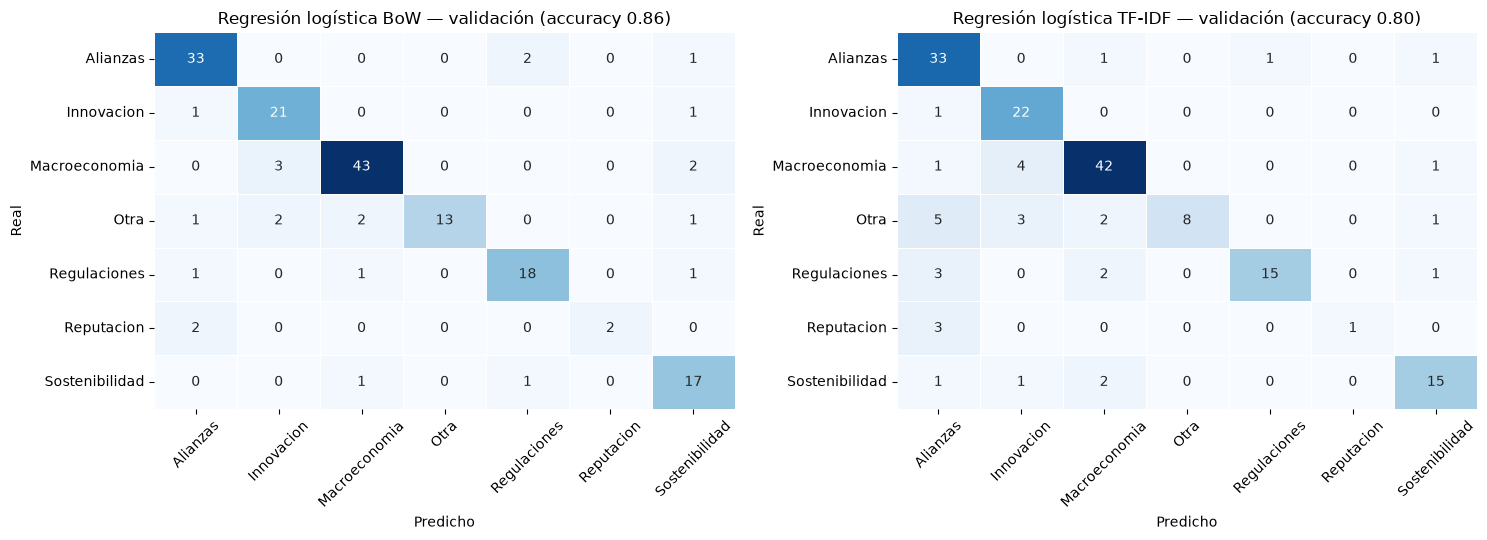

In [12]:
# --- 2.3 Matrices de confusión en validación ---

clases = lr_bow.classes_
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax, (nombre, pred) in zip(axes, [("BoW", pred_val_bow), ("TF-IDF", pred_val_tfidf)]):
    cm = confusion_matrix(y_val, pred, labels=clases)
    acc = accuracy_score(y_val, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=clases, yticklabels=clases, ax=ax,
                linewidths=0.5, linecolor="white")
    ax.set_title(f"Regresión logística {nombre} — validación (accuracy {acc:.2f})")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("reporte/img/confusion_lr_validacion.png", dpi=120)
plt.show()

# Se guardan para el análisis de errores de la Sección 6.
cm_bow   = confusion_matrix(y_val, pred_val_bow,   labels=clases)
cm_tfidf = confusion_matrix(y_val, pred_val_tfidf, labels=clases)

In [13]:
# --- 2.4 ¿Por qué gana BoW? Separar el efecto de la normalización del efecto del IDF ---
# TF-IDF hace DOS cosas a la vez sobre la bolsa de palabras: pondera cada término por su IDF y
# normaliza cada documento a norma L2 = 1. Para saber cuál de las dos explica la diferencia se
# evalúa una representación intermedia: BoW normalizado a L2 = 1 pero SIN IDF.

variantes = [
    ("BoW crudo",                X_train_bow,             X_val_bow),
    ("BoW normalizado L2",       normalize(X_train_bow),  normalize(X_val_bow)),
    ("TF-IDF (normaliza + IDF)", X_train_tfidf,           X_val_tfidf),
]

print(f"{'Representación':<26}{'acc train':>10}{'acc val':>9}{'F1 macro val':>14}{'iteraciones':>13}")
for nombre, Xtr, Xva in variantes:
    modelo = LogisticRegression(random_state=RANDOM_STATE).fit(Xtr, y_train)
    pred = modelo.predict(Xva)
    print(f"{nombre:<26}{accuracy_score(y_train, modelo.predict(Xtr)):>10.4f}"
          f"{accuracy_score(y_val, pred):>9.4f}{f1_score(y_val, pred, average='macro'):>14.4f}"
          f"{int(modelo.n_iter_[0]):>13}")

# La causa es de ESCALA, no de información. En BoW la magnitud de un documento no está acotada:
sumas = np.asarray(X_val_bow.sum(axis=1)).ravel()
normas_tfidf = np.sqrt(np.asarray(X_val_tfidf.multiply(X_val_tfidf).sum(axis=1)).ravel())
print()
print(f"BoW    — conteos por documento: mínimo {sumas.min()}, mediana {int(np.median(sumas))}, "
      f"máximo {sumas.max()}  ({sumas.max() / sumas.min():.0f}× entre el mayor y el menor)")
print(f"TF-IDF — norma L2 por documento: de {normas_tfidf.min():.3f} a {normas_tfidf.max():.3f}  "
      f"(todos idénticos por construcción)")

Representación             acc train  acc val  F1 macro val  iteraciones


BoW crudo                     1.0000   0.8647        0.8286           55
BoW normalizado L2            0.9395   0.8235        0.7566           35


TF-IDF (normaliza + IDF)      0.9508   0.8000        0.7263           33

BoW    — conteos por documento: mínimo 27, mediana 242, máximo 1011  (37× entre el mayor y el menor)
TF-IDF — norma L2 por documento: de 1.000 a 1.000  (todos idénticos por construcción)


In [14]:
# --- 2.5 Consecuencia de la escala: tamaño de los puntajes y calibración ---
# Con features más pequeñas, los puntajes z también son más pequeños. Y como la penalización l2
# actúa sobre los pesos con la misma fuerza (C=1.0 en ambos), TF-IDF queda mucho más regularizado.

print(f"{'':8}{'|z| máx medio':>15}{'confianza media':>18}{'conf > 0.99':>13}{'corr(largo, |z|)':>19}")
for nombre, modelo, Xva in [("BoW", lr_bow, X_val_bow), ("TF-IDF", lr_tfidf, X_val_tfidf)]:
    z = np.asarray(Xva @ modelo.coef_.T + modelo.intercept_)
    z_max = np.abs(z).max(axis=1)
    confianza = modelo.predict_proba(Xva).max(axis=1)
    correlacion = np.corrcoef(sumas, z_max)[0, 1]
    print(f"{nombre:<8}{z_max.mean():>15.2f}{confianza.mean():>18.4f}"
          f"{(confianza > 0.99).sum():>10}/170{correlacion:>19.3f}")

print()
print("Los puntajes de BoW son ~4× más grandes, y su tamaño depende de cuán largo sea el documento")
print("(correlación +0.66): un texto largo acumula más conteos y empuja |z| hacia arriba, saturando")
print("la softmax. En TF-IDF esa dependencia desaparece (+0.08) porque todos los documentos tienen")
print("la misma norma. Se retoma en la Sección 5: si la diferencia es de escala frente a una misma")
print("penalización, subir C debería permitirle a TF-IDF alcanzar a BoW.")

          |z| máx medio   confianza media  conf > 0.99   corr(largo, |z|)
BoW                7.77            0.9021        77/170              0.655
TF-IDF             1.89            0.5078         0/170              0.079

Los puntajes de BoW son ~4× más grandes, y su tamaño depende de cuán largo sea el documento
(correlación +0.66): un texto largo acumula más conteos y empuja |z| hacia arriba, saturando
la softmax. En TF-IDF esa dependencia desaparece (+0.08) porque todos los documentos tienen
la misma norma. Se retoma en la Sección 5: si la diferencia es de escala frente a una misma
penalización, subir C debería permitirle a TF-IDF alcanzar a BoW.


### 2.6 Resultados y discusión

| Representación | Conjunto | Accuracy | F1 macro | F1 ponderado |
|---|---|---|---|---|
| **BoW** | entrenamiento | **1.0000** | 1.0000 | 1.0000 |
| **BoW** | **validación** | **0.8647** | **0.8286** | **0.8633** |
| TF-IDF | entrenamiento | 0.9508 | 0.9043 | 0.9486 |
| TF-IDF | validación | 0.8000 | 0.7263 | 0.7893 |

#### ¿Hay indicios de overfitting?

Sí, y en BoW es del libro: **accuracy 1.0000 en entrenamiento**. El modelo no se aproxima a los
datos de entrenamiento, los reproduce sin un solo error. Con 10,968 features para 793 documentos
hay muchísimas más dimensiones que ejemplos, así que las siete categorías son linealmente
separables y el optimizador encuentra pesos que las separan perfectamente. Buena parte de esos
pesos se apoya en palabras que aparecen una o dos veces en todo el corpus: sirven para memorizar
un documento concreto y no dicen nada sobre uno nuevo.

La brecha entrenamiento → validación es de **13.5 puntos** en BoW y **15.1** en TF-IDF, muy
parecidas a las que dejó Naive Bayes en el Lab #3 (14.1 y 16.3). Pero memorizar no impidió
generalizar: 0.8647 sobre documentos que nunca vio es el mejor resultado obtenido hasta ahora en
este corpus, mejor incluso que el 0.8353 del Naive Bayes con vocabulario recortado a 1,000
términos. Es la distinción que conviene no perder: **la brecha mide cuánto se memorizó, no cuánto
se fracasa**. Un modelo con brecha grande y validación alta está aprovechando bien la señal real
además de memorizar ruido; lo preocupante sería una brecha grande con validación baja.

La forma de cerrar esa brecha es limitar la capacidad del modelo. En el Lab #3 se hizo recortando
el vocabulario (`max_features=1000`, que bajó la brecha de 14.1 a 5.3 puntos). En regresión
logística hay una palanca más directa —el parámetro `C`— y es el objeto de la Sección 5.

#### ¿Qué representación obtuvo mejor desempeño?

**BoW, por 6.5 puntos de accuracy** (0.8647 contra 0.8000) y 10.2 de F1 macro. El orden entre
representaciones es el mismo del Lab #3, pero la distancia se desplomó: con Naive Bayes, TF-IDF
perdía por **25.3 puntos**; aquí pierde por 6.5.

Lo que cambió es que **la regresión logística rescata a TF-IDF**. En el Lab #3, `MultinomialNB` con
TF-IDF se derrumbaba a 0.5471 y predecía Macroeconomia 109 veces de 170, sin predecir Reputacion
ni una sola vez: los pesos TF-IDF, normalizados a L2 = 1, aportaban tan poca evidencia (9.9 de
"masa" por documento contra 261.5 en BoW) que el prior de la categoría mayoritaria decidía casi
todo. La regresión logística con la misma matriz sube a 0.8000 —**+25.3 puntos**— y su reparto de
predicciones deja de estar sesgado: predice Macroeconomia 49 veces cuando hay 48 reales. La razón
es estructural: Naive Bayes **suma** un prior estimado por separado a una evidencia cuya magnitud
depende de la representación, mientras que la regresión logística aprende el sesgo `b` y los pesos
`w` **conjuntamente**, así que el sesgo no puede dominar por un accidente de escala.

#### Entonces, ¿por qué sigue ganando BoW?

La celda 2.4 separa las dos cosas que TF-IDF hace a la vez, evaluando una representación
intermedia —BoW normalizado a L2 = 1, pero sin IDF:

| Representación | acc entrenamiento | acc validación | F1 macro |
|---|---|---|---|
| BoW crudo | 1.0000 | **0.8647** | **0.8286** |
| BoW normalizado L2 | 0.9395 | 0.8235 | 0.7566 |
| TF-IDF (normaliza + IDF) | 0.9508 | 0.8000 | 0.7263 |

La caída se reparte: **4.1 puntos los cuesta normalizar** y **2.4 más los cuesta el IDF**. O sea que
lo que más pesa no es la ponderación IDF sino el haber destruido la magnitud de los conteos — el
mismo diagnóstico del Lab #3, aunque por un mecanismo distinto y mucho más leve.

Y el mecanismo es de **escala frente a regularización**, no de información. En BoW la magnitud de un
documento no está acotada: en validación van de 27 a 1,011 conteos, **37× entre el mayor y el
menor**. En TF-IDF todos valen exactamente 1. Al achicar las features, los puntajes se achican con
ellas (|z| medio de 7.77 a 1.89), pero la penalización `l2` sigue aplicándose con la misma fuerza,
porque `C = 1.0` en ambos modelos. **TF-IDF no está peor representado: está más regularizado.**
La comprobación está en la Sección 5, donde con `C = 1000` TF-IDF alcanza exactamente el 0.8647
de BoW.

#### Una ventaja de TF-IDF que la accuracy no muestra: la calibración

|  | \|z\| máx medio | Confianza media | Documentos con confianza > 0.99 | corr(largo, \|z\|) |
|---|---|---|---|---|
| BoW | 7.77 | 0.9021 | **77 de 170** | **+0.655** |
| TF-IDF | 1.89 | 0.5078 | **0 de 170** | +0.079 |

BoW acierta más, pero está **sobreconfiado**: se declara seguro por encima del 99 % en 77 de 170
documentos, y el tamaño de sus puntajes correlaciona con **el largo del documento** (+0.66). Un
texto largo acumula más conteos, `z` crece y la softmax satura — de modo que la "seguridad" del
modelo mide en parte cuántas palabras tenía la noticia. En TF-IDF esa dependencia prácticamente
desaparece (+0.08) y ningún documento supera el 99 %.

Esto importa para dos cosas más adelante. Para el **análisis de errores** (Sección 6): un modelo que
se equivoca con 99 % de certeza repite el problema que se le documentó a Naive Bayes en el Lab #3.
Y para la pregunta de la **Sección 7** sobre cuándo se prefiere un modelo u otro: si lo que se
necesita son probabilidades bien calibradas y no solo la etiqueta ganadora, el modelo con mejor
accuracy no es automáticamente el mejor.

## 3. Interpretación de pesos

La regresión logística aprende **un peso por característica y por categoría**, optimizando
directamente la separación entre clases, mientras que Naive Bayes estima cada `P(wᵢ|c)` por
separado contando ocurrencias. Esta sección mira qué palabras quedaron con más peso en el mejor
modelo de la Sección 2 —**regresión logística con BoW**, 0.8647 de accuracy en validación— y las
compara contra las de mayor verosimilitud del Naive Bayes del Lab #3.

Las categorías elegidas son **Macroeconomia**, la mejor clasificada del corpus, y el par
**Alianzas / Regulaciones**, que en el Lab #3 fue el par que Naive Bayes más confundía entre sí
(7 errores cruzados de 34), para poder enlazar con el análisis de errores de la Sección 6.

In [15]:
# --- 3.1 Glosario raíz -> palabra legible (heredado del Lab #3) ---
# Los vectorizadores trabajan sobre las raíces del stemmer ('regulacion', 'alianz'), que son
# incómodas de leer. Para cada raíz se guarda la forma completa con la que aparece más veces.

formas = {}
for legibles, raices in zip(df_prep["tokens_norm"], df_prep["tokens_stem"]):
    for palabra, raiz in zip(legibles, raices):
        formas.setdefault(raiz, Counter())[palabra] += 1

glosario = {raiz: c.most_common(1)[0][0] for raiz, c in formas.items()}


def legible(raiz):
    """Traduce una raíz a su palabra completa más frecuente."""
    return glosario.get(raiz, raiz)


CATEGORIAS = ["Macroeconomia", "Alianzas", "Regulaciones"]
print("Ejemplos:", {r: legible(r) for r in ["regulacion", "alianz", "sostenibil", "inflacion"]})

Ejemplos: {'regulacion': 'regulacion', 'alianz': 'alianza', 'sostenibil': 'sostenibilidad', 'inflacion': 'inflación'}


In [16]:
# --- 3.2 Las 15 palabras con mayor peso positivo y negativo por categoría ---
# coef_[k] son los pesos de la categoría k. Un peso positivo empuja el documento HACIA esa
# categoría; uno negativo, en contra. Naive Bayes no tiene equivalente de lo segundo.

def top_pesos(categoria, n=15):
    """Devuelve (positivos, negativos): los n términos de mayor y menor peso de una categoría."""
    k = list(lr_bow.classes_).index(categoria)
    w = lr_bow.coef_[k]
    positivos = [(legible(vocab_bow[j]), w[j]) for j in np.argsort(-w)[:n]]
    negativos = [(legible(vocab_bow[j]), w[j]) for j in np.argsort(w)[:n]]
    return positivos, negativos


for categoria in CATEGORIAS:
    pos, neg = top_pesos(categoria)
    print("=" * 78)
    print(f"{categoria}")
    print("=" * 78)
    print("  A favor :", ", ".join(f"{p} ({v:+.2f})" for p, v in pos))
    print("  En contra:", ", ".join(f"{p} ({v:+.2f})" for p, v in neg))
    print()

Macroeconomia
  A favor : inflación (+0.47), aumento (+0.35), economía (+0.32), año (+0.28), bbva (+0.27), precios (+0.24), ipc (+0.24), liras (+0.20), público (+0.20), research (+0.20), índice (+0.19), incremento (+0.19), alza (+0.19), inmobiliario (+0.18), crecimiento (+0.18)
  En contra: personas (-0.25), digital (-0.23), usuarios (-0.21), financiera (-0.21), tecnología (-0.21), alianza (-0.21), colombia (-0.20), empresas (-0.19), frente (-0.19), regulación (-0.19), compañía (-0.18), desarrollo (-0.18), millones (-0.16), busca (-0.15), grupo (-0.15)

Alianzas
  A favor : alianza (+1.01), programa (+0.25), colombia (+0.24), millones (+0.23), acuerdo (+0.22), colombianos (+0.22), entrega (+0.21), compañía (+0.21), política (+0.20), bolsa (+0.19), acceso (+0.18), aliados (+0.18), perú (+0.16), medio (+0.16), estratégica (+0.16)
  En contra: bbva (-0.82), regulación (-0.36), podcast (-0.24), hablar (-0.18), actividad (-0.16), aumento (-0.16), reputación (-0.16), uber (-0.16), público (-

In [17]:
# --- 3.3 Las mismas categorías vistas por Naive Bayes: mayor P(w|c) ---

def top_verosimilitud(categoria, n=15):
    """Los n términos de mayor P(w|c) según el Naive Bayes del Lab #3."""
    k = list(nb_bow.classes_).index(categoria)
    orden = np.argsort(-nb_bow.feature_log_prob_[k])[:n]
    return [legible(vocab_bow[j]) for j in orden]


print("Palabras con mayor P(w|c) (Naive Bayes) frente a mayor peso positivo (regresión logística)")
print()
for categoria in CATEGORIAS:
    pos, _ = top_pesos(categoria)
    palabras_lr = [p for p, _ in pos]
    palabras_nb = top_verosimilitud(categoria)
    comunes = set(palabras_lr) & set(palabras_nb)
    print(f"{categoria}")
    print("   Naive Bayes:", ", ".join(palabras_nb))
    print("   Reg. logíst:", ", ".join(palabras_lr))
    print(f"   En común: {len(comunes)} de 15 -> {sorted(comunes)}")
    print()

# El problema documentado en el Lab #3: Alianzas y Regulaciones compartían buena parte de su
# vocabulario más probable, y por eso el modelo las confundía. ¿Le pasa lo mismo a los pesos?
print("=" * 78)
print("Solapamiento ENTRE Alianzas y Regulaciones (el par confundido del Lab #3)")
print("=" * 78)
nb_a, nb_b = set(top_verosimilitud("Alianzas")), set(top_verosimilitud("Regulaciones"))
lr_a = {p for p, _ in top_pesos("Alianzas")[0]}
lr_b = {p for p, _ in top_pesos("Regulaciones")[0]}
print(f"  Naive Bayes, mayor P(w|c) : {len(nb_a & nb_b)} de 15 compartidas -> {sorted(nb_a & nb_b)}")
print(f"  Reg. logística, mayor peso: {len(lr_a & lr_b)} de 15 compartidas -> {sorted(lr_a & lr_b)}")

Palabras con mayor P(w|c) (Naive Bayes) frente a mayor peso positivo (regresión logística)

Macroeconomia
   Naive Bayes: inflación, economía, precios, aumento, año, mayor, bbva, mes, tasa, crecimiento, país, nivel, alimentos, subida, banco
   Reg. logíst: inflación, aumento, economía, año, bbva, precios, ipc, liras, público, research, índice, incremento, alza, inmobiliario, crecimiento
   En común: 7 de 15 -> ['aumento', 'año', 'bbva', 'crecimiento', 'economía', 'inflación', 'precios']

Alianzas
   Naive Bayes: alianza, colombia, millones, país, nueva, empresas, desarrollo, mercado, parte, servicios, hace, presidente, mejor, año, pago
   Reg. logíst: alianza, programa, colombia, millones, acuerdo, colombianos, entrega, compañía, política, bolsa, acceso, aliados, perú, medio, estratégica
   En común: 3 de 15 -> ['alianza', 'colombia', 'millones']

Regulaciones
   Naive Bayes: regulación, país, trabajo, empresas, mercado, nueva, servicios, debe, dijo, economía, hace, operaciones, colomb

In [18]:
# --- 3.4 ¿Palabras frecuentes o palabras discriminativas? ---
# Si una palabra aparece en el top-15 de varias categorías a la vez, no sirve para distinguirlas.
# Se cuenta, sobre las 7 x 15 = 105 posiciones, cuántos términos DISTINTOS hay y cuántos son
# exclusivos de una sola categoría.

def diversidad(matriz, etiqueta):
    tops = [set(np.argsort(-matriz[k])[:15]) for k in range(len(lr_bow.classes_))]
    conteo = Counter(j for s in tops for j in s)
    exclusivos = sum(1 for v in conteo.values() if v == 1)
    print(f"{etiqueta:<28} {len(conteo):>3} términos distintos en 105 posiciones | "
          f"exclusivos de 1 categoría: {exclusivos} ({exclusivos / len(conteo):.0%})")
    print(f"{'':28} más repetidos: "
          + ", ".join(f"{legible(vocab_bow[j])} (en {v})" for j, v in conteo.most_common(4)))
    return conteo


print("Sobre las 7 categorías × 15 palabras = 105 posiciones:")
print()
diversidad(nb_bow.feature_log_prob_, "Naive Bayes, mayor P(w|c)")
print()
diversidad(lr_bow.coef_, "Reg. logística, mayor peso")

Sobre las 7 categorías × 15 palabras = 105 posiciones:

Naive Bayes, mayor P(w|c)     64 términos distintos en 105 posiciones | exclusivos de 1 categoría: 41 (64%)
                             más repetidos: empresas (en 5), nueva (en 4), país (en 4), bbva (en 4)

Reg. logística, mayor peso   100 términos distintos en 105 posiciones | exclusivos de 1 categoría: 97 (97%)
                             más repetidos: bbva (en 4), colombia (en 2), podcast (en 2), bolsa (en 1)


Counter({np.int64(1217): 4,
         np.int64(2186): 2,
         np.int64(8017): 2,
         np.int64(1410): 1,
         np.int64(419): 1,
         np.int64(164): 1,
         np.int64(420): 1,
         np.int64(6826): 1,
         np.int64(3850): 1,
         np.int64(8044): 1,
         np.int64(8336): 1,
         np.int64(2192): 1,
         np.int64(2257): 1,
         np.int64(4051): 1,
         np.int64(84): 1,
         np.int64(6644): 1,
         np.int64(7863): 1,
         np.int64(9986): 1,
         np.int64(9794): 1,
         np.int64(7810): 1,
         np.int64(3718): 1,
         np.int64(296): 1,
         np.int64(7848): 1,
         np.int64(2251): 1,
         np.int64(9969): 1,
         np.int64(4530): 1,
         np.int64(7571): 1,
         np.int64(1682): 1,
         np.int64(10462): 1,
         np.int64(4446): 1,
         np.int64(8449): 1,
         np.int64(5411): 1,
         np.int64(1092): 1,
         np.int64(8167): 1,
         np.int64(2663): 1,
         np.int64(8905): 

In [19]:
# --- 3.5 Una palabra, siete pesos: el caso de 'bbva' ---
# El corpus son noticias publicadas por BBVA, así que 'bbva' aparece por todas partes: en 338 de
# los 793 documentos de entrenamiento (43 %). Es el ejemplo más claro de la diferencia entre
# estimar frecuencias y optimizar una separación.

j_bbva = bow_vectorizer.vocabulary_["bbva"]
docs_con_bbva = int((X_train_bow[:, j_bbva] > 0).sum())
print(f"'bbva' aparece en {docs_con_bbva} de {X_train_bow.shape[0]} documentos de entrenamiento "
      f"({docs_con_bbva / X_train_bow.shape[0]:.0%})")
print()

comparacion = []
for k, categoria in enumerate(lr_bow.classes_):
    puesto = int(np.where(np.argsort(-nb_bow.feature_log_prob_[k]) == j_bbva)[0][0]) + 1
    comparacion.append({
        "Peso (reg. logística)": lr_bow.coef_[k, j_bbva],
        "Puesto en P(w|c) (NB)": f"{puesto:,} de {len(vocab_bow):,}",
    })

print(pd.DataFrame(comparacion, index=lr_bow.classes_).to_string(
    formatters={"Peso (reg. logística)": "{:+.3f}".format}))

'bbva' aparece en 338 de 793 documentos de entrenamiento (43%)



               Peso (reg. logística) Puesto en P(w|c) (NB)
Alianzas                      -0.824       2,531 de 10,968
Innovacion                    +0.631           1 de 10,968
Macroeconomia                 +0.266           7 de 10,968
Otra                          +0.196           2 de 10,968
Regulaciones                  -0.396       3,495 de 10,968
Reputacion                    -0.151       7,820 de 10,968
Sostenibilidad                +0.278           2 de 10,968


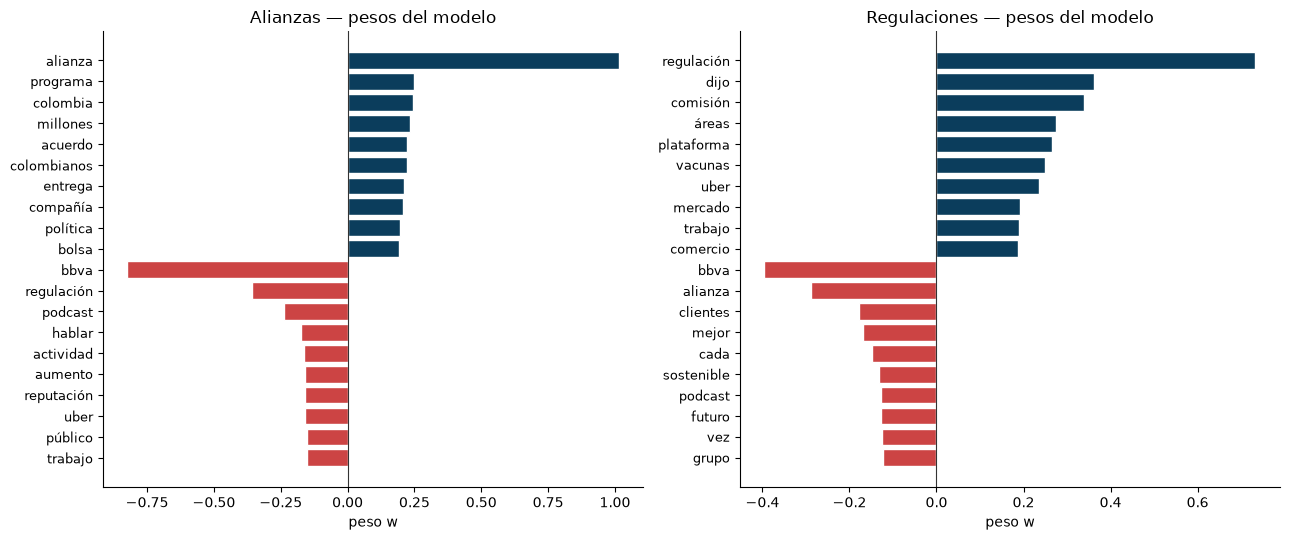

In [20]:
# --- 3.6 Gráfico de los pesos del par confundido ---
# Se dibujan las 10 palabras más a favor y las 10 más en contra de cada categoría del par.

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, categoria in zip(axes, ["Alianzas", "Regulaciones"]):
    pos, neg = top_pesos(categoria, n=10)
    datos = list(reversed(neg)) + list(reversed(pos))
    etiquetas = [p for p, _ in datos]
    valores = [v for _, v in datos]
    colores = ["#c44" if v < 0 else "#0b3d5c" for v in valores]

    ax.barh(range(len(valores)), valores, color=colores, edgecolor="white")
    ax.set_yticks(range(len(valores)))
    ax.set_yticklabels(etiquetas, fontsize=9)
    ax.axvline(0, color="#333", linewidth=0.8)
    ax.set_title(f"{categoria} — pesos del modelo")
    ax.set_xlabel("peso w")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("reporte/img/pesos_par_confundido.png", dpi=120)
plt.show()

### 3.7 Resultados y discusión

#### ¿Tienen sentido esas palabras como evidencia a favor y en contra?

Sí, y las dos direcciones se leen sin esfuerzo. En **Macroeconomia** los pesos positivos son
`inflación` (+0.47), `aumento`, `economía`, `precios`, `ipc`, `índice`, `alza`, `crecimiento`:
el vocabulario del tema. Los negativos son `personas`, `digital`, `usuarios`, `tecnología`,
`alianza`, `regulación` — es decir, el vocabulario **de las otras categorías**. El modelo no solo
aprendió a qué se parece una noticia macroeconómica, sino a qué **no** se parece.

En el par confundido la simetría es exacta:

| Término | Peso en Alianzas | Peso en Regulaciones |
|---|---|---|
| `alianza` | **+1.01** | −0.29 |
| `regulación` | −0.36 | **+0.73** |
| `bbva` | **−0.82** | −0.40 |

Cada categoría empuja hacia arriba su palabra insignia y **hacia abajo la de su rival**. Eso es
exactamente lo que significa "optimizar la separación conjuntamente": el peso de `regulación` en
Alianzas no sale de contar cuántas veces aparece la palabra en noticias de alianzas, sino de que
bajarlo ayuda a no confundir las dos categorías.

No todo es vocabulario temático, y conviene decirlo. Aparecen términos que son **pistas de la
fuente y no del tema**: `research` (+0.20 en Macroeconomia) viene de "BBVA Research", el servicio
de estudios que publica los informes de inflación; `podcast` pesa en otra categoría por el formato
de la publicación, no por su contenido. El modelo aprovecha regularidades del corpus que no
generalizarían a noticias de otro medio. Es coherente con la accuracy de 1.0000 en entrenamiento
vista en la Sección 2.

#### ¿Coinciden con las palabras de mayor P(w|c) de Naive Bayes?

**Coinciden en parte, y el grado de coincidencia depende de si la categoría tiene vocabulario
propio.**

| Categoría | Palabras en común (top-15) |
|---|---|
| Macroeconomia | **7 de 15** — `inflación`, `economía`, `precios`, `aumento`, `año`, `bbva`, `crecimiento` |
| Regulaciones | 4 de 15 — `regulación`, `dijo`, `mercado`, `trabajo` |
| Alianzas | **3 de 15** — `alianza`, `colombia`, `millones` |

Macroeconomia tiene léxico inequívocamente suyo, así que los dos métodos lo encuentran. Alianzas
no: en el Lab #2 ya se había medido que era la categoría **menos cohesionada** del corpus
(razón intra/inter de 1.12×, prácticamente sin cohesión), porque "alianza" es un tipo de evento y
no un tema. Ahí los dos métodos divergen casi por completo.

La diferencia de fondo es **qué clase de palabra premia cada uno**, y se puede cuantificar. Sobre
las 7 × 15 = 105 posiciones del top de cada categoría:

| | Términos distintos | Exclusivos de una sola categoría |
|---|---|---|
| Naive Bayes, mayor `P(w|c)` | 64 | 41 (**64 %**) |
| Reg. logística, mayor peso | 100 | 97 (**97 %**) |

Naive Bayes repite: `empresas` está en el top-15 de **cinco** categorías, `país`, `nueva` y `bbva`
en cuatro. Son palabras frecuentes en todas partes, y una palabra que caracteriza a cinco
categorías no distingue ninguna. La regresión logística casi no repite: el 97 % de sus términos de
mayor peso pertenece a una sola categoría.

**Ese es el mecanismo del error que el Lab #3 documentó.** Alianzas y Regulaciones compartían
7 de sus 15 palabras más probables (`colombia`, `empresas`, `mercado`, `país`, `servicios`,
`nueva`, `hace`), y por eso, si la noticia no decía literalmente "alianza" o "regulación", Naive
Bayes decidía con vocabulario que no distinguía nada. En los pesos de la regresión logística el
solapamiento entre esas mismas dos categorías es de **0 de 15**.

#### A qué se deben las diferencias

Naive Bayes estima `P(wᵢ|c)` **contando dentro de cada categoría, aislada del resto**. Una palabra
sube en el ranking por ser frecuente ahí, sin importar que sea igual de frecuente en las otras
seis. La regresión logística ajusta los 76,776 pesos **a la vez**, y lo que premia es reducir el
error de clasificación: una palabra que aparece por todas partes no baja ese error, así que no
recibe peso alto — salvo que sirva para descartar.

El caso de **`bbva`** lo muestra completo. Es un corpus de noticias publicadas por BBVA, así que la
palabra aparece en **338 de 793 documentos (43 %)**:

| Categoría | Peso (reg. logística) | Puesto en `P(w|c)` (Naive Bayes) |
|---|---|---|
| Innovacion | **+0.631** | **1** de 10,968 |
| Sostenibilidad | +0.278 | 2 |
| Otra | +0.196 | 2 |
| Macroeconomia | +0.266 | 7 |
| Reputacion | −0.151 | 7,820 |
| Regulaciones | −0.396 | 3,495 |
| Alianzas | **−0.824** | 2,531 |

Para Naive Bayes, `bbva` es **la palabra más característica de Innovacion** y la segunda de otras
dos categorías: información inútil, porque caracteriza a casi todas. La regresión logística la usa
al revés y con provecho: le da el peso **más negativo de toda la categoría Alianzas** (−0.824).
Traducido, el modelo aprendió que *"si la noticia menciona a BBVA, probablemente no es una
alianza"* — las alianzas se anuncian nombrando al socio. Es una inferencia que la estimación
aislada de `P(wᵢ|c)` **no puede expresar en ninguna forma**, porque todos sus valores son
log-probabilidades negativas y una palabra solo puede aportar evidencia a favor, con más o menos
fuerza. Los pesos negativos no son un detalle técnico: son la mitad de la información del modelo,
y son el 60 % de los pesos (45,774 de 76,776).

## 4. Comparación con Naive Bayes

Esta sección compara las cuatro combinaciones posibles —Naive Bayes y regresión logística, cada uno
con bolsa de palabras y con TF-IDF— **sobre el conjunto de prueba**, que hasta ahora no se había
tocado. Los cuatro modelos usan la configuración por defecto de scikit-learn, las mismas
particiones y los mismos vectorizadores, así que la comparación aísla el efecto del algoritmo y de
la representación.

Los tiempos de entrenamiento se miden aquí y no se copian del Lab #3, para que las cuatro cifras
salgan de la misma máquina y la misma ejecución. Se toma la **mediana de siete repeticiones**,
porque una medición aislada de unos pocos milisegundos es demasiado ruidosa.

In [21]:
# --- 4.1 Las cuatro combinaciones sobre el conjunto de prueba ---

def cronometrar(constructor, X, y, repeticiones=7):
    """Entrena varias veces y devuelve (modelo, mediana del tiempo en segundos)."""
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        modelo = constructor().fit(X, y)
        tiempos.append(time.perf_counter() - inicio)
    return modelo, float(np.median(tiempos))


combinaciones = [
    ("Naive Bayes",    "BoW",    lambda: MultinomialNB(),                        X_train_bow,   X_test_bow),
    ("Naive Bayes",    "TF-IDF", lambda: MultinomialNB(),                        X_train_tfidf, X_test_tfidf),
    ("Reg. logística", "BoW",    lambda: LogisticRegression(random_state=RANDOM_STATE), X_train_bow,   X_test_bow),
    ("Reg. logística", "TF-IDF", lambda: LogisticRegression(random_state=RANDOM_STATE), X_train_tfidf, X_test_tfidf),
]

resultados, pred_test = [], {}
for modelo_nombre, repr_nombre, constructor, X_tr, X_te in combinaciones:
    modelo, segundos = cronometrar(constructor, X_tr, y_train)
    pred = modelo.predict(X_te)
    pred_test[(modelo_nombre, repr_nombre)] = pred
    resultados.append({
        "Modelo": modelo_nombre,
        "Representación": repr_nombre,
        "Accuracy": accuracy_score(y_test, pred),
        "F1 macro": f1_score(y_test, pred, average="macro"),
        "F1 ponderado": f1_score(y_test, pred, average="weighted"),
        "Entrenamiento (ms)": segundos * 1000,
    })

comparativa = pd.DataFrame(resultados).sort_values("Accuracy", ascending=False)
print("Conjunto de prueba (171 documentos)")
print(comparativa.to_string(index=False, formatters={
    "Accuracy": "{:.4f}".format, "F1 macro": "{:.4f}".format,
    "F1 ponderado": "{:.4f}".format, "Entrenamiento (ms)": "{:.1f}".format}))
print()

# Los dos Naive Bayes deben reproducir las cifras del Lab #3 sobre prueba: 0.8246 y 0.5731.
assert round(comparativa.set_index(["Modelo", "Representación"]).loc[("Naive Bayes", "BoW"), "Accuracy"], 4) == 0.8246
assert round(comparativa.set_index(["Modelo", "Representación"]).loc[("Naive Bayes", "TF-IDF"), "Accuracy"], 4) == 0.5731
print("Naive Bayes reproduce sus cifras de prueba del Laboratorio #3 (0.8246 y 0.5731).")

lento = comparativa["Entrenamiento (ms)"].max() / comparativa["Entrenamiento (ms)"].min()
print(f"El modelo más lento tarda {lento:.0f}× lo que el más rápido.")

Conjunto de prueba (171 documentos)
        Modelo Representación Accuracy F1 macro F1 ponderado Entrenamiento (ms)
Reg. logística            BoW   0.8713   0.8631       0.8703              235.6
Reg. logística         TF-IDF   0.8421   0.7699       0.8349              134.1
   Naive Bayes            BoW   0.8246   0.7599       0.8199                1.7
   Naive Bayes         TF-IDF   0.5731   0.3939       0.5052                1.5

Naive Bayes reproduce sus cifras de prueba del Laboratorio #3 (0.8246 y 0.5731).
El modelo más lento tarda 162× lo que el más rápido.


In [22]:
# --- 4.2 ¿La diferencia es grande o marginal? Test de McNemar ---
# Con 171 documentos de prueba, 1 documento vale 0.58 puntos de accuracy: conviene comprobar si
# las diferencias observadas se distinguen del ruido. McNemar mira solo los documentos donde los
# dos modelos DISCREPAN y pregunta si el reparto es más desigual de lo que daría el azar.

def mcnemar(par_a, par_b):
    """Compara dos modelos sobre prueba. Devuelve (aciertos solo de A, solo de B, p-valor)."""
    acierta_a = pred_test[par_a] == y_test.values
    acierta_b = pred_test[par_b] == y_test.values
    solo_a = int((acierta_a & ~acierta_b).sum())
    solo_b = int((~acierta_a & acierta_b).sum())
    p = binomtest(solo_a, solo_a + solo_b, 0.5).pvalue
    return solo_a, solo_b, p


print(f"1 documento de prueba = {100 / len(y_test):.2f} puntos de accuracy  (n = {len(y_test)})")
print()
print(f"{'Comparación':<46}{'solo A':>8}{'solo B':>8}{'p-valor':>12}")
for etiqueta, a, b in [
    ("Reg. logística BoW  vs Naive Bayes BoW",     ("Reg. logística", "BoW"),    ("Naive Bayes", "BoW")),
    ("Reg. logística TFIDF vs Naive Bayes TF-IDF", ("Reg. logística", "TF-IDF"), ("Naive Bayes", "TF-IDF")),
    ("Reg. logística BoW  vs Reg. logística TFIDF",("Reg. logística", "BoW"),    ("Reg. logística", "TF-IDF")),
]:
    solo_a, solo_b, p = mcnemar(a, b)
    print(f"{etiqueta:<46}{solo_a:>8}{solo_b:>8}{p:>12.2e}")

1 documento de prueba = 0.58 puntos de accuracy  (n = 171)

Comparación                                     solo A  solo B     p-valor
Reg. logística BoW  vs Naive Bayes BoW              15       7    1.34e-01
Reg. logística TFIDF vs Naive Bayes TF-IDF          49       3    1.04e-11
Reg. logística BoW  vs Reg. logística TFIDF         11       6    3.32e-01


In [23]:
# --- 4.3 ¿De dónde sale la ganancia? F1 por categoría en prueba ---
# La accuracy sube 4.7 puntos pero el F1 macro sube 10.3: la mejora no está repartida por igual.

clases_orden = y_train.value_counts().sort_values().index   # de la categoría más pequeña a la mayor
f1_nb = f1_score(y_test, pred_test[("Naive Bayes", "BoW")],    average=None, labels=clases_orden, zero_division=0)
f1_lr = f1_score(y_test, pred_test[("Reg. logística", "BoW")], average=None, labels=clases_orden, zero_division=0)

por_categoria = pd.DataFrame({
    "Docs entrenamiento": y_train.value_counts().reindex(clases_orden),
    "Docs prueba":        y_test.value_counts().reindex(clases_orden),
    "F1 Naive Bayes":     f1_nb,
    "F1 Reg. logística":  f1_lr,
    "Δ":                  f1_lr - f1_nb,
}, index=clases_orden)

print("Ambos con BoW, sobre prueba (ordenado de la categoría más pequeña a la más grande)")
print(por_categoria.to_string(float_format=lambda v: f"{v:.3f}"))

Ambos con BoW, sobre prueba (ordenado de la categoría más pequeña a la más grande)
                Docs entrenamiento  Docs prueba  F1 Naive Bayes  F1 Reg. logística      Δ
Type                                                                                     
Reputacion                      18            4           0.400              0.857  0.457
Sostenibilidad                  87           18           0.895              0.865 -0.030
Otra                            89           20           0.743              0.850  0.107
Regulaciones                    99           21           0.789              0.811  0.021
Innovacion                     106           23           0.780              0.875  0.095
Alianzas                       171           37           0.824              0.907  0.083
Macroeconomia                  223           48           0.889              0.878 -0.011


### 4.4 Resultados y discusión

| Modelo | Representación | Accuracy | F1 macro | F1 ponderado | Entrenamiento |
|---|---|---|---|---|---|
| **Reg. logística** | **BoW** | **0.8713** | **0.8631** | **0.8703** | ≈ 238 ms |
| Reg. logística | TF-IDF | 0.8421 | 0.7699 | 0.8349 | ≈ 138 ms |
| Naive Bayes | BoW | 0.8246 | 0.7599 | 0.8199 | **≈ 1.7 ms** |
| Naive Bayes | TF-IDF | 0.5731 | 0.3939 | 0.5052 | ≈ 1.5 ms |

Los dos Naive Bayes reproducen exactamente sus cifras del Lab #3 (0.8246 y 0.5731), lo que
confirma una vez más que las particiones y los vectorizadores son los mismos.

#### ¿Qué modelo obtuvo mejor desempeño? ¿La diferencia es grande o marginal?

Gana la **regresión logística con BoW**, y además es el mejor resultado obtenido sobre este corpus
en los cuatro laboratorios: 0.8713 de accuracy, por encima del 0.8596 del Naive Bayes con
vocabulario recortado que había ganado el Lab #3.

Pero "grande o marginal" depende de contra qué se compare, y conviene no responderlo a ojo: con
171 documentos de prueba, **un documento vale 0.58 puntos de accuracy**. El test de McNemar —que
mira solo los documentos donde los dos modelos discrepan— separa los dos casos con claridad:

| Comparación | Acierta solo A | Acierta solo B | p-valor |
|---|---|---|---|
| Reg. logística BoW vs Naive Bayes BoW | 15 | 7 | **0.13** |
| Reg. logística TF-IDF vs Naive Bayes TF-IDF | 49 | 3 | **1.0 × 10⁻¹¹** |
| Reg. logística BoW vs Reg. logística TF-IDF | 11 | 6 | 0.33 |

**Con la misma representación BoW, la ventaja de la regresión logística es marginal.** Son 4.7
puntos de accuracy, sí, pero se reducen a **ocho documentos netos de 171**, y un reparto de 15
contra 7 es perfectamente compatible con el azar (p = 0.13). Sobre este corpus, con esta
representación, no hay evidencia de que un algoritmo sea mejor que el otro para acertar la etiqueta.

**Con TF-IDF, en cambio, la diferencia es abrumadora:** 49 documentos que la regresión logística
acierta y Naive Bayes no, contra 3 en sentido contrario (p ≈ 10⁻¹¹). Es el mismo fenómeno de la
Sección 2: TF-IDF no daña a la regresión logística como destruye a Naive Bayes.

#### Un matiz que la accuracy esconde: dónde está la ganancia

La accuracy sube 4.7 puntos frente a Naive Bayes, pero el **F1 macro sube 10.3** (0.7599 → 0.8631).
Esa distancia entre las dos métricas significa que la mejora no está repartida por igual:

| Categoría | Docs entrenamiento | F1 Naive Bayes | F1 Reg. logística | Δ |
|---|---|---|---|---|
| Reputacion | 18 | 0.400 | 0.857 | **+0.457** |
| Otra | 89 | 0.743 | 0.850 | +0.107 |
| Innovacion | 106 | 0.780 | 0.875 | +0.095 |
| Alianzas | 171 | 0.824 | 0.907 | +0.083 |
| Regulaciones | 99 | 0.789 | 0.811 | +0.021 |
| Macroeconomia | 223 | 0.889 | 0.878 | −0.011 |
| Sostenibilidad | 87 | 0.895 | 0.865 | −0.030 |

**Casi toda la ganancia está en las categorías pequeñas y medianas.** En las dos mejor
representadas la regresión logística incluso pierde un poco. Reputacion, con 18 documentos de
entrenamiento, pasa de un F1 de 0.400 a 0.857. Como la accuracy la dominan las categorías grandes,
apenas registra ese salto; el F1 macro, que pesa las siete por igual, sí.

Es exactamente el mismo patrón que el Lab #3 encontró al recortar el vocabulario a 1,000 términos
(Reputacion 0.40 → 0.89), y llegado por un camino distinto. Allí se arregló **quitando** las
palabras raras que hacían ruido en una categoría con pocos datos; aquí se arregla dejando que la
optimización conjunta le **reste peso** a esas mismas palabras. Dos formas de controlar la misma
patología.

#### Cómo se relaciona esto con la forma en que cada modelo calcula sus pesos

Naive Bayes estima cada `P(wᵢ|c)` **aisladamente**, contando dentro de su categoría y asumiendo
independencia condicional. Es una cuenta cerrada, sin iteraciones: agrupar, sumar, tomar
logaritmos. Por eso entrena en **1.7 ms**. Y por eso mismo su estimación es frágil donde hay pocos
datos: con 18 documentos, las frecuencias de Reputacion son casi todas ruido, y no hay nada en el
método que lo corrija, porque cada palabra se estima sin mirar a las demás ni a las otras
categorías.

La regresión logística ajusta los 76,776 pesos **a la vez**, minimizando iterativamente el error de
clasificación con `lbfgs`. Nada la obliga a que los pesos de una categoría sean probabilidades ni a
que sumen 1, así que puede usar un término como evidencia en contra —`bbva` con −0.824 en Alianzas,
de la Sección 3— y puede compensar palabras correlacionadas repartiendo el peso entre ellas en vez
de acumularlo. Eso es lo que rescata a las categorías pequeñas: no necesita estimar bien
`P(w|Reputacion)` con 18 documentos, le basta con encontrar qué separa a Reputacion del resto.

El precio es el tiempo: **≈ 238 ms contra ≈ 1.7 ms con la misma representación, unas 140
veces más** (159× entre el más lento y el más rápido de los cuatro). Puesto en perspectiva, sigue
siendo un costo trivial —vectorizar el corpus tarda más que entrenar cualquiera de los cuatro
modelos—, pero es la diferencia entre contar y optimizar, y crece con el tamaño del corpus.

## 5. Efecto de la regularización

Esta sección no aparece numerada en el enunciado, pero la tabla de entregables pide explícitamente
el **efecto de la regularización** y remite al análisis como "sección 7", mientras que la pregunta 2
de ese análisis llama "sección 6" al análisis de errores que el PDF numera como 5. Hay un
corrimiento de una sección, igual que ocurrió en el Lab #3, y este es el hueco.

La regularización es la palanca que la regresión logística tiene y Naive Bayes no. El parámetro
**`C` es el inverso de la fuerza de penalización**: `C` grande significa poca regularización (pesos
libres de crecer) y `C` pequeño, mucha (pesos empujados hacia cero). Hay dos cosas que comprobar:

1. La curva clásica de sobreajuste, que en el Lab #3 se obtuvo recortando el vocabulario
   (`max_features`) y que aquí se obtiene moviendo `C`.
2. La hipótesis que quedó abierta en la Sección 2: si la desventaja de TF-IDF es un problema de
   **escala frente a una misma penalización** y no de información, entonces subir `C` debería
   permitirle alcanzar a BoW.

Todo se mide **sobre validación**. El conjunto de prueba ya se usó en la Sección 4 y no se vuelve a
tocar: elegir aquí un valor de `C` mirando prueba lo convertiría en un segundo conjunto de
validación.

In [24]:
# --- 5.1 Barrido de C con penalización l2 ---
# Se recorre C en escala logarítmica y se registra el desempeño en entrenamiento y validación,
# más la norma de los pesos, que es lo que la penalización controla directamente.

valores_C = [0.001, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000]

barrido = []
for nombre, X_tr, X_va in [("BoW", X_train_bow, X_val_bow), ("TF-IDF", X_train_tfidf, X_val_tfidf)]:
    for C in valores_C:
        modelo = LogisticRegression(random_state=RANDOM_STATE, C=C, max_iter=5000).fit(X_tr, y_train)
        acc_tr = accuracy_score(y_train, modelo.predict(X_tr))
        acc_va = accuracy_score(y_val, modelo.predict(X_va))
        barrido.append({
            "Representación": nombre, "C": C,
            "acc train": acc_tr, "acc val": acc_va,
            "F1 macro val": f1_score(y_val, modelo.predict(X_va), average="macro"),
            "brecha": acc_tr - acc_va,
            "||w||": np.linalg.norm(modelo.coef_),
        })

barrido = pd.DataFrame(barrido)
for nombre in ["BoW", "TF-IDF"]:
    sub = barrido[barrido["Representación"] == nombre].drop(columns="Representación")
    print(f"===== {nombre} =====")
    print(sub.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    mejor = sub.loc[sub["F1 macro val"].idxmax()]
    print(f"  Mejor F1 macro en validación: C = {mejor['C']:g}  ->  "
          f"acc {mejor['acc val']:.4f}, F1 macro {mejor['F1 macro val']:.4f}")
    print()

===== BoW =====
        C  acc train  acc val  F1 macro val  brecha   ||w||
   0.0010     0.8209   0.7176        0.5953  0.1033  0.6524
   0.0100     0.9849   0.8471        0.8137  0.1378  1.8586
   0.0300     1.0000   0.8588        0.8245  0.1412  2.6962
   0.1000     1.0000   0.8647        0.8286  0.1353  3.7232
   0.3000     1.0000   0.8647        0.8286  0.1353  4.7059
   1.0000     1.0000   0.8647        0.8286  0.1353  5.8262
   3.0000     1.0000   0.8647        0.8286  0.1353  6.9014
  10.0000     1.0000   0.8647        0.8286  0.1353  8.2845
  30.0000     1.0000   0.8529        0.8170  0.1471  9.8726
 100.0000     1.0000   0.8765        0.8392  0.1235 11.8890
 300.0000     1.0000   0.8765        0.8392  0.1235 11.8365
1000.0000     1.0000   0.8765        0.8392  0.1235 11.9989
  Mejor F1 macro en validación: C = 100  ->  acc 0.8765, F1 macro 0.8392

===== TF-IDF =====
        C  acc train  acc val  F1 macro val  brecha    ||w||
   0.0010     0.2812   0.2824        0.0629 -0.001

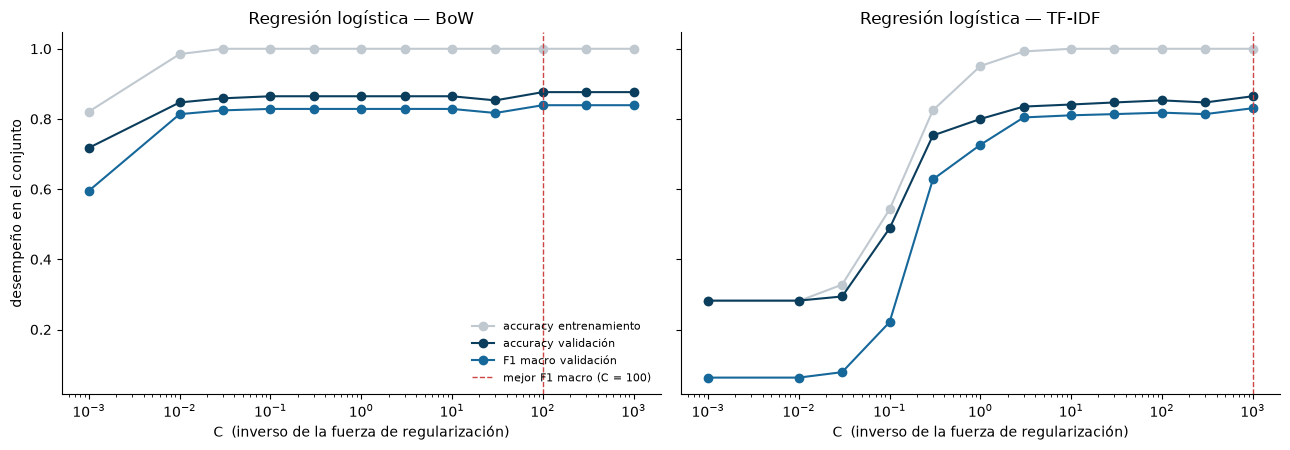

In [25]:
# --- 5.2 La curva de regularización ---

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)

for ax, nombre in zip(axes, ["BoW", "TF-IDF"]):
    sub = barrido[barrido["Representación"] == nombre]
    ax.plot(sub["C"], sub["acc train"],    "o-", color="#c0c8d0", label="accuracy entrenamiento")
    ax.plot(sub["C"], sub["acc val"],      "o-", color="#0b3d5c", label="accuracy validación")
    ax.plot(sub["C"], sub["F1 macro val"], "o-", color="#16679a", label="F1 macro validación")

    mejor_C = sub.loc[sub["F1 macro val"].idxmax(), "C"]
    ax.axvline(mejor_C, color="#c44", linestyle="--", linewidth=1,
               label=f"mejor F1 macro (C = {mejor_C:g})")

    ax.set_xscale("log")
    ax.set_xlabel("C  (inverso de la fuerza de regularización)")
    ax.set_title(f"Regresión logística — {nombre}")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("desempeño en el conjunto")
axes[0].legend(frameon=False, fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("reporte/img/regularizacion.png", dpi=120)
plt.show()

In [26]:
# --- 5.3 ¿Alcanza TF-IDF a BoW? (hipótesis abierta en la Sección 2) ---
# En la Sección 2 se midió que TF-IDF pierde por 6.5 puntos con C = 1.0, y se propuso que la causa
# es de escala: sus features son ~37x más pequeñas, así que la MISMA penalización lo regulariza
# mucho más. Si eso es cierto, compensar con C debería igualar los resultados.

comparacion = barrido.pivot(index="C", columns="Representación", values="acc val")
comparacion["diferencia"] = comparacion["BoW"] - comparacion["TF-IDF"]
normas = barrido.pivot(index="C", columns="Representación", values="||w||")
comparacion["||w|| BoW"] = normas["BoW"]
comparacion["||w|| TF-IDF"] = normas["TF-IDF"]

print("Accuracy en validación y norma de los pesos, por valor de C")
print(comparacion.to_string(float_format=lambda v: f"{v:.4f}"))
print()

acc_bow_defecto   = comparacion.loc[1, "BoW"]
acc_tfidf_maximo  = comparacion["TF-IDF"].max()
print(f"BoW con C = 1 (por defecto):     {acc_bow_defecto:.4f}")
print(f"TF-IDF con C = 1000:             {comparacion.loc[1000, 'TF-IDF']:.4f}")
print(f"¿Lo alcanza? {comparacion.loc[1000, 'TF-IDF'] >= acc_bow_defecto}")
print()
print(f"Para lograrlo, TF-IDF necesita pesos {normas.loc[1000, 'TF-IDF'] / normas.loc[1, 'BoW']:.0f}× "
      f"más grandes: ||w|| = {normas.loc[1000, 'TF-IDF']:.1f} frente a {normas.loc[1, 'BoW']:.1f}.")

Accuracy en validación y norma de los pesos, por valor de C
Representación    BoW  TF-IDF  diferencia  ||w|| BoW  ||w|| TF-IDF
C                                                                 
0.001          0.7176  0.2824      0.4353     0.6524        0.0654
0.010          0.8471  0.2824      0.5647     1.8586        0.6370
0.030          0.8588  0.2941      0.5647     2.6962        1.8029
0.100          0.8647  0.4882      0.3765     3.7232        5.1018
0.300          0.8647  0.7529      0.1118     4.7059       11.4853
1.000          0.8647  0.8000      0.0647     5.8262       23.1821
3.000          0.8647  0.8353      0.0294     6.9014       37.2942
10.000         0.8647  0.8412      0.0235     8.2845       54.2407
30.000         0.8529  0.8471      0.0059     9.8726       70.1364
100.000        0.8765  0.8529      0.0235    11.8890       87.7080
300.000        0.8765  0.8471      0.0294    11.8365      105.8828
1000.000       0.8765  0.8647      0.0118    11.9989      134.4226

B

In [27]:
# --- 5.4 Penalización l1: en vez de encoger los pesos, anularlos ---
# l2 encoge todos los pesos pero no anula ninguno (Sección 1: 0 pesos exactamente cero). l1 sí:
# empuja a cero los que no aportan, y hace SELECCIÓN DE CARACTERÍSTICAS.
# Se usa el solver 'saga' y no 'liblinear' porque saga soporta l1 manteniendo el modelo
# MULTINOMIAL; liblinear haría one-vs-rest y no sería el mismo modelo que se viene analizando.

esparsidad = []
for penalty, C, solver in [("l2", 1, "lbfgs"), ("l2", 100, "lbfgs"),
                           ("l1", 0.1, "saga"), ("l1", 0.5, "saga"),
                           ("l1", 1, "saga"),   ("l1", 5, "saga")]:
    modelo = LogisticRegression(random_state=RANDOM_STATE, penalty=penalty, C=C,
                                solver=solver, max_iter=3000).fit(X_train_bow, y_train)
    pred = modelo.predict(X_val_bow)
    activos = int((modelo.coef_ != 0).sum())
    # Un término puede tener peso en varias categorías: se cuentan también los términos usados.
    terminos = int((np.abs(modelo.coef_).sum(axis=0) > 0).sum())
    esparsidad.append({
        "penalty": penalty, "C": C,
        "acc val": accuracy_score(y_val, pred),
        "F1 macro val": f1_score(y_val, pred, average="macro"),
        "Pesos activos": activos,
        "% del total": activos / modelo.coef_.size * 100,
        "Términos usados": terminos,
    })

esparsidad = pd.DataFrame(esparsidad)
print(f"Todos con BoW ({len(vocab_bow):,} términos, {lr_bow.coef_.size:,} pesos posibles)")
print(esparsidad.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Todos con BoW (10,968 términos, 76,776 pesos posibles)
penalty        C  acc val  F1 macro val  Pesos activos  % del total  Términos usados
     l2   1.0000   0.8647        0.8286          76776     100.0000            10968
     l2 100.0000   0.8765        0.8392          76776     100.0000            10968
     l1   0.1000   0.8235        0.8343            185       0.2410              136
     l1   0.5000   0.8412        0.8053            507       0.6604              330
     l1   1.0000   0.8529        0.8169            747       0.9730              456
     l1   5.0000   0.8353        0.7997           2660       3.4646             1342


In [28]:
# --- 5.5 ¿Qué términos sobreviven a l1? ---
# Con C = 0.1 el modelo se queda con una fracción mínima del vocabulario. Vale la pena ver cuáles.

lr_l1 = LogisticRegression(random_state=RANDOM_STATE, penalty="l1", C=0.1,
                           solver="saga", max_iter=3000).fit(X_train_bow, y_train)

usados = np.where(np.abs(lr_l1.coef_).sum(axis=0) > 0)[0]
print(f"Términos con algún peso distinto de cero: {len(usados)} de {len(vocab_bow):,} "
      f"({len(usados) / len(vocab_bow):.1%} del vocabulario)")
print()

for k, categoria in enumerate(lr_l1.classes_):
    w = lr_l1.coef_[k]
    vivos = np.where(w != 0)[0]
    orden = vivos[np.argsort(-np.abs(w[vivos]))][:8]
    print(f"{categoria:<15} ({len(vivos):>3} términos): "
          + ", ".join(f"{legible(vocab_bow[j])} ({w[j]:+.2f})" for j in orden))

Términos con algún peso distinto de cero: 136 de 10,968 (1.2% del vocabulario)

Alianzas        ( 22 términos): alianza (+1.95), bbva (-0.92), colombia (+0.36), perú (+0.28), programa (+0.22), proceso (+0.17), colombianos (+0.15), compañía (+0.14)
Innovacion      ( 32 términos): colombia (-0.39), bbva (+0.27), podcast (+0.18), usuarios (+0.18), equipo (+0.16), tecnología (+0.16), puede (+0.12), digital (+0.12)
Macroeconomia   ( 29 términos): inflación (+0.94), precios (+0.26), pymes (+0.26), ipc (+0.26), aumento (+0.26), inmobiliario (+0.25), año (+0.22), economía (+0.22)
Otra            ( 28 términos): sostenible (+0.31), entidad (+0.29), frente (+0.24), colombia (+0.23), dicho (+0.21), información (-0.20), crédito (+0.18), ubicó (+0.16)
Regulaciones    ( 27 términos): regulación (+0.95), bbva (-0.60), dijo (+0.28), industria (+0.25), comisión (+0.24), gobierno (+0.20), trabajo (+0.17), uber (+0.16)
Reputacion      (  8 términos): reputación (+1.01), bbva (-0.44), bitcoin (+0.16), cri

### 5.6 Resultados y discusión

#### La curva de regularización

| C | BoW acc train | BoW acc val | BoW F1 macro | TF-IDF acc val | TF-IDF F1 macro |
|---|---|---|---|---|---|
| 0.001 | 0.8209 | 0.7176 | 0.5953 | **0.2824** | **0.0629** |
| 0.01 | 0.9849 | 0.8471 | 0.8137 | 0.2824 | 0.0629 |
| 0.1 | 1.0000 | 0.8647 | 0.8286 | 0.4882 | 0.2209 |
| 1 (defecto) | 1.0000 | 0.8647 | 0.8286 | 0.8000 | 0.7263 |
| 10 | 1.0000 | 0.8647 | 0.8286 | 0.8412 | 0.8104 |
| **100** | 1.0000 | **0.8765** | **0.8392** | 0.8529 | 0.8180 |
| 1000 | 1.0000 | 0.8765 | 0.8392 | **0.8647** | 0.8306 |

Las dos representaciones se comportan de forma **completamente distinta**, y esa diferencia es el
resultado principal de la sección.

**En BoW la curva es casi plana.** Entre `C = 0.1` y `C = 1000` la accuracy de validación se mueve
entre 0.8647 y 0.8765 — poco más de un punto, que son **dos documentos de 170**. Regularizar más
solo empeora: con `C = 0.001` cae a 0.7176. El óptimo aparente (`C = 100`, 0.8765) está dentro del
ruido y no justifica cambiar el valor por defecto.

**En TF-IDF la curva es una rampa.** Va de 0.2824 a 0.8647 de forma monótona, sin llegar a doblar
hacia abajo ni siquiera con `C = 1000`. Es exactamente lo contrario de una curva de sobreajuste: en
todo el rango explorado, TF-IDF **necesita más capacidad, no menos**.

#### La hipótesis de la Sección 2 se confirma

En la Sección 2 se propuso que TF-IDF no está peor representado sino **más regularizado**, porque
sus features son ~37× más pequeñas y `C = 1.0` las castiga proporcionalmente mucho más. La
comprobación es directa:

> **BoW con `C = 1` da 0.8647. TF-IDF con `C = 1000` da 0.8647.** El mismo número exacto.

Y el precio de llegar ahí se lee en la norma de los pesos: TF-IDF necesita `‖w‖ = 134.4` frente a
`‖w‖ = 5.8` de BoW, unas **23 veces más grandes**. Es justo lo que compensa que sus entradas sean
más chicas. La desventaja de TF-IDF de la Sección 2 no era de información: era el resultado de
comparar dos representaciones a escalas distintas bajo una misma penalización.

#### El colapso de TF-IDF con `C` pequeño repite el error de Naive Bayes

Con `C ≤ 0.01`, TF-IDF se derrumba a **accuracy 0.2824 y F1 macro 0.0629**. Ese 0.2824 no es un
número cualquiera: es prácticamente la **línea base de clase mayoritaria** (Macroeconomia es el
28.1 % del corpus; ver Sección 7). El modelo predice siempre la categoría más frecuente.

El mecanismo es idéntico al que hundió a Naive Bayes con TF-IDF en el Lab #3, aunque el camino sea
otro. Allí, la evidencia léxica quedaba tan pequeña frente al prior que el prior decidía. Aquí, la
penalización aplasta los pesos hasta `‖w‖ = 0.07`, el término `w·x` se vuelve despreciable frente al
sesgo `b`, y **el sesgo decide**, que es el papel que jugaba el prior. Dos modelos distintos, dos
causas distintas, el mismo síntoma: cuando la evidencia del texto se apaga, gana la clase mayoritaria.

#### `l1`: seleccionar características en vez de encoger

`l2` encoge todos los pesos pero no anula ninguno: los 76,776 son distintos de cero (Sección 1).
`l1` sí los anula, y el resultado es drástico:

| penalty | C | acc val | F1 macro val | Pesos activos | % del total | Términos usados |
|---|---|---|---|---|---|---|
| l2 | 1 | 0.8647 | 0.8286 | 76,776 | 100 % | 10,968 |
| l2 | 100 | 0.8765 | 0.8392 | 76,776 | 100 % | 10,968 |
| **l1** | **0.1** | 0.8235 | **0.8343** | **185** | **0.2 %** | **136** |
| l1 | 0.5 | 0.8412 | 0.8053 | 507 | 0.7 % | 330 |
| l1 | 1 | 0.8529 | 0.8169 | 747 | 1.0 % | 456 |
| l1 | 5 | 0.8353 | 0.7997 | 2,660 | 3.5 % | 1,342 |

**Con `l1` y `C = 0.1` el modelo usa 185 pesos de 76,776 —el 0.2 %— y obtiene un F1 macro de
0.8343, por encima del 0.8286 del modelo `l2` completo.** Se puede tirar el 99.8 % de los pesos y
no perder nada en F1 macro; la accuracy sí baja unos 4 puntos, porque la métrica que menos sufre es
la que trata a todas las categorías por igual.

Los términos que sobreviven son legibles uno por uno, y algunas categorías se resuelven con
apenas un puñado. **Reputacion, la categoría con 18 documentos de entrenamiento y la peor
clasificada por Naive Bayes (F1 0.400), se decide con 8 términos**: `reputación` (+1.01),
`bbva` (−0.44), `bitcoin`, `criptomonedas`, `empresas`, `grupo`, `sector`, `tecnología`. Con menos
datos, menos parámetros: es exactamente lo que le faltaba a Naive Bayes, que estimaba 10,968
probabilidades para esa categoría a partir de 18 documentos.

Esto conecta directamente con el mejor modelo del Lab #3, `max_features=1000`. Allí se llegó a la
conclusión de que unos pocos cientos o miles de términos bastan, **recortando por frecuencia y a
priori**. Aquí se llega al mismo sitio, pero la selección la **aprende el modelo**, quedándose con
los términos que separan las categorías y no con los más frecuentes. Es la misma idea de fondo —
controlar la capacidad— por dos caminos distintos, y el segundo es más fino, porque no depende de
adivinar el número correcto de palabras.

#### Relación con el sobreajuste de la Sección 2

Un matiz importante: **en BoW, regularizar no cierra la brecha entrenamiento–validación.** La
accuracy de entrenamiento se queda en 1.0000 para todo `C ≥ 0.03`, y la brecha oscila entre 12.3 y
14.7 puntos sin bajar. Solo se reduce con `C = 0.001` (10.3 puntos), y ahí el modelo ya se ha roto
(0.7176 en validación). Contrasta con el Lab #3, donde recortar el vocabulario a 1,000 términos sí
la bajó de 14.1 a 5.3 puntos.

La lección es que **la brecha no es el objetivo**. Ambas palancas controlan la capacidad del modelo,
pero `C` la controla sin quitar features: los 10,968 términos siguen ahí y el modelo puede seguir
memorizando el conjunto de entrenamiento aunque sus pesos sean pequeños. Lo que importa es el
desempeño sobre datos nuevos, y ahí el modelo con brecha de 13.5 puntos (0.8647) le gana al del
Lab #3 con brecha de 5.3 (0.8353).

## 6. Análisis de errores

Se analizan los errores del mejor modelo del laboratorio —**regresión logística con BoW**— sobre el
conjunto de validación, que es donde el Lab #3 hizo su propio análisis de errores. Usar el mismo
conjunto permite responder la pregunta que pide el enunciado: si los documentos que falla la
regresión logística **son los mismos** que fallaba Naive Bayes, otros distintos, o el mismo tipo de
confusión.

In [29]:
# --- 6.1 Cuántos errores, y entre qué categorías ---

# Los índices del DataFrame no coinciden con las filas de la matriz: hace falta el mapeo (igual
# que en el Lab #3), para poder recuperar el texto original de cualquier documento mal clasificado.
posicion_val = {ix: k for k, ix in enumerate(y_val.index)}

errores_lr = pred_val_bow != y_val.values
errores_nb = nb_bow.predict(X_val_bow) != y_val.values
pred_val_nb = nb_bow.predict(X_val_bow)

print(f"Errores en validación (170 documentos)")
print(f"  Regresión logística BoW: {errores_lr.sum():>3}  (accuracy {1 - errores_lr.mean():.4f})")
print(f"  Naive Bayes BoW (Lab #3): {errores_nb.sum():>3}  (accuracy {1 - errores_nb.mean():.4f})")
print()

# Pares confundidos MUTUAMENTE: se suman las dos direcciones de la matriz de confusión.
def pares_confundidos(cm, etiquetas):
    pares = []
    for i in range(len(etiquetas)):
        for j in range(i + 1, len(etiquetas)):
            total = cm[i, j] + cm[j, i]
            if total:
                pares.append((total, etiquetas[i], etiquetas[j], cm[i, j], cm[j, i]))
    return sorted(pares, reverse=True)


cm_nb = confusion_matrix(y_val, pred_val_nb, labels=clases)
for etiqueta, cm in [("Regresión logística BoW", cm_bow), ("Naive Bayes BoW (Lab #3)", cm_nb)]:
    print(f"{etiqueta} — pares más confundidos entre sí:")
    for total, a, b, ab, ba in pares_confundidos(cm, clases)[:4]:
        print(f"   {a} <-> {b}: {total} errores  ({a}->{b}: {ab}, {b}->{a}: {ba})")
    print()

Errores en validación (170 documentos)
  Regresión logística BoW:  23  (accuracy 0.8647)
  Naive Bayes BoW (Lab #3):  34  (accuracy 0.8000)

Regresión logística BoW — pares más confundidos entre sí:
   Macroeconomia <-> Sostenibilidad: 3 errores  (Macroeconomia->Sostenibilidad: 2, Sostenibilidad->Macroeconomia: 1)
   Innovacion <-> Macroeconomia: 3 errores  (Innovacion->Macroeconomia: 0, Macroeconomia->Innovacion: 3)
   Alianzas <-> Regulaciones: 3 errores  (Alianzas->Regulaciones: 2, Regulaciones->Alianzas: 1)
   Regulaciones <-> Sostenibilidad: 2 errores  (Regulaciones->Sostenibilidad: 1, Sostenibilidad->Regulaciones: 1)

Naive Bayes BoW (Lab #3) — pares más confundidos entre sí:
   Alianzas <-> Regulaciones: 7 errores  (Alianzas->Regulaciones: 4, Regulaciones->Alianzas: 3)
   Innovacion <-> Otra: 4 errores  (Innovacion->Otra: 0, Otra->Innovacion: 4)
   Innovacion <-> Macroeconomia: 4 errores  (Innovacion->Macroeconomia: 0, Macroeconomia->Innovacion: 4)
   Otra <-> Sostenibilidad: 2 

In [30]:
# --- 6.2 ¿Son los mismos documentos que fallaba Naive Bayes? ---

ids_lr = set(y_val.index[errores_lr])
ids_nb = set(y_val.index[errores_nb])

print(f"Documentos mal clasificados por la regresión logística: {len(ids_lr)}")
print(f"Documentos mal clasificados por Naive Bayes:            {len(ids_nb)}")
print()
print(f"  Fallan los DOS:            {len(ids_lr & ids_nb):>3}  "
      f"({len(ids_lr & ids_nb) / len(ids_lr):.0%} de los errores de la regresión logística)")
print(f"  Corrige la reg. logística: {len(ids_nb - ids_lr):>3}  (errores de Naive Bayes que ya no ocurren)")
print(f"  Errores nuevos:            {len(ids_lr - ids_nb):>3}  (los falla la reg. logística y Naive Bayes no)")
print()

print("Los errores nuevos, con la confianza del modelo al cometerlos:")
confianza_lr = lr_bow.predict_proba(X_val_bow).max(axis=1)
for ix in sorted(ids_lr - ids_nb):
    k = posicion_val[ix]
    print(f"   doc {ix:>5}: real {y_val.loc[ix]:<15} predicho {pred_val_bow[k]:<15} "
          f"confianza {confianza_lr[k]:.3f}")

Documentos mal clasificados por la regresión logística: 23
Documentos mal clasificados por Naive Bayes:            34

  Fallan los DOS:             19  (83% de los errores de la regresión logística)
  Corrige la reg. logística:  15  (errores de Naive Bayes que ya no ocurren)
  Errores nuevos:              4  (los falla la reg. logística y Naive Bayes no)

Los errores nuevos, con la confianza del modelo al cometerlos:
   doc   248: real Innovacion      predicho Alianzas        confianza 0.528
   doc   360: real Innovacion      predicho Sostenibilidad  confianza 0.697
   doc   466: real Alianzas        predicho Regulaciones    confianza 0.743
   doc  1110: real Sostenibilidad  predicho Macroeconomia   confianza 0.998


In [31]:
# --- 6.3 Qué palabras llevan al modelo a equivocarse ---
# Misma idea que el Lab #3, adaptada: allí se ponderaba la fila del documento por la diferencia
# de log-verosimilitudes entre la clase predicha y la real; aquí, por la diferencia de PESOS.
# El resultado es la contribución de cada término a la diferencia de puntaje z.

def culpables(indice_doc, n=6):
    """Términos que más empujaron el documento de su categoría real hacia la predicha."""
    k = posicion_val[indice_doc]
    fila = X_val_bow[k].toarray().ravel()
    real, predicha = y_val.loc[indice_doc], pred_val_bow[k]
    i_real = list(lr_bow.classes_).index(real)
    i_pred = list(lr_bow.classes_).index(predicha)

    aporte = fila * (lr_bow.coef_[i_pred] - lr_bow.coef_[i_real])
    orden = np.argsort(-aporte)[:n]
    return real, predicha, [(legible(vocab_bow[j]), int(fila[j]), aporte[j]) for j in orden if aporte[j] > 0]


# Se revisan los errores del par Alianzas <-> Regulaciones, el que Naive Bayes más confundía en el
# Lab #3, para poder comparar sobre las mismas categorías.
del_par = [ix for ix in y_val.index[errores_lr]
           if {y_val.loc[ix], pred_val_bow[posicion_val[ix]]} == {"Alianzas", "Regulaciones"}]

print(f"Errores entre Alianzas y Regulaciones: {len(del_par)} documentos")
print("=" * 78)
for ix in del_par:
    real, predicha, terminos = culpables(ix)
    k = posicion_val[ix]
    print(f"doc {ix} — real: {real} | predicho: {predicha} | confianza {confianza_lr[k]:.3f}")
    print(f"   \"{df_prep.loc[ix, 'news'][:130].strip()}...\"")
    print("   Términos que lo empujaron: "
          + ", ".join(f"{p} (×{n}, {a:+.2f})" for p, n, a in terminos))
    print()

Errores entre Alianzas y Regulaciones: 3 documentos
doc 466 — real: Alianzas | predicho: Regulaciones | confianza 0.743
   "El favorito para la presidencia Luiz Inacio Lula da Silva pidió una revisión radical de las políticas de Brasil hacia la Amazonía..."
   Términos que lo empujaron: regulación (×2, +2.18), dijo (×3, +1.32), mercado (×2, +0.45), áreas (×1, +0.39), trabajo (×1, +0.34), grandes (×4, +0.33)

doc 756 — real: Regulaciones | predicho: Alianzas | confianza 0.941
   "El Ministerio de Ciencia Tecnología e Innovación MinCiencias y la Comisión de Regulación de Comunicaciones CRC firmaron un conveni..."
   Términos que lo empujaron: alianza (×1, +1.30), millones (×3, +0.81), parte (×3, +0.54), innovación (×4, +0.35), investigación (×4, +0.34), desarrollo (×3, +0.29)

doc 72 — real: Alianzas | predicho: Regulaciones | confianza 0.934
   "Hace exactamente cuatro años escribí en este espació Que me multen a mí también describiendo un fenómeno que no se ha resuelto. La..."
   Térmi

In [32]:
# --- 6.4 El documento 667: independencia condicional frente a pesos conjuntos ---
# En el Lab #3 este documento fue el ejemplo del problema: Naive Bayes lo mandó a Regulaciones con
# el 100 % de certeza porque 'uber', 'taxi', 'taxistas' y 'tarifas' son la MISMA señal, pero se
# suman como si fueran evidencia independiente. La regresión logística lo acierta.

doc = 667
k = posicion_val[doc]
fila = X_val_bow[k].toarray().ravel()
i_ali = list(lr_bow.classes_).index("Alianzas")
i_reg = list(lr_bow.classes_).index("Regulaciones")

print(f"doc {doc} — real: {y_val.loc[doc]}")
print(f'   "{df_prep.loc[doc, "news"][:150].strip()}..."')
print(f"   Naive Bayes predice {pred_val_nb[k]} con confianza "
      f"{nb_bow.predict_proba(X_val_bow[k]).max():.4f}")
print(f"   Reg. logística predice {pred_val_bow[k]} con confianza {confianza_lr[k]:.4f}")
print()

# Aporte de cada término a la diferencia (Regulaciones - Alianzas). Positivo = empuja al error.
print(f"   {'término':<12}{'×':>3}{'Naive Bayes':>16}{'Reg. logística':>18}")
grupo_uber = ["uber", "taxi", "taxist", "tarif"]
for raiz in grupo_uber + ["alianz"]:
    j = bow_vectorizer.vocabulary_[raiz]
    n = int(fila[j])
    aporte_nb = n * (nb_bow.feature_log_prob_[i_reg, j] - nb_bow.feature_log_prob_[i_ali, j])
    aporte_lr = n * (lr_bow.coef_[i_reg, j] - lr_bow.coef_[i_ali, j])
    marca = "  <- una sola aparición" if raiz == "alianz" else ""
    print(f"   {legible(raiz):<12}{n:>3}{aporte_nb:>16.2f}{aporte_lr:>18.2f}{marca}")

j_ali = bow_vectorizer.vocabulary_["alianz"]
idx_grupo = [bow_vectorizer.vocabulary_[r] for r in grupo_uber]
for etiqueta, matriz, sesgo in [
    ("Naive Bayes",    nb_bow.feature_log_prob_, nb_bow.class_log_prior_),
    ("Reg. logística", lr_bow.coef_,             lr_bow.intercept_),
]:
    diferencia = fila * (matriz[i_reg] - matriz[i_ali])
    grupo = diferencia[idx_grupo].sum()
    contra = abs(diferencia[j_ali])
    total = diferencia.sum() + (sesgo[i_reg] - sesgo[i_ali])
    print()
    print(f"   {etiqueta}:")
    print(f"     el grupo uber/taxi/taxistas/tarifas aporta {grupo:+.2f} hacia Regulaciones")
    print(f"     'alianza', con una sola aparición, aporta  {contra:.2f} en contra "
          f"({contra / grupo:.0%} de lo anterior)")
    print(f"     saldo total (con el sesgo): {total:+.2f} -> "
          f"{'Regulaciones' if total > 0 else 'Alianzas'}")

doc 667 — real: Alianzas
   "Uber Taxi cumple este mes su primer aniversario en Colombia esta solución nació de la alianza entre Uber y TaxExpress con el objetivo de brindar nueva..."
   Naive Bayes predice Regulaciones con confianza 1.0000
   Reg. logística predice Alianzas con confianza 0.6427

   término       ×     Naive Bayes    Reg. logística
   uber          7           28.60              2.75
   taxi          3            2.73             -0.03
   taxistas      2            4.59              0.11
   tarifas       1            1.24              0.04
   alianza       1           -3.93             -1.30  <- una sola aparición

   Naive Bayes:
     el grupo uber/taxi/taxistas/tarifas aporta +37.16 hacia Regulaciones
     'alianza', con una sola aparición, aporta  3.93 en contra (11% de lo anterior)
     saldo total (con el sesgo): +12.11 -> Regulaciones

   Reg. logística:
     el grupo uber/taxi/taxistas/tarifas aporta +2.87 hacia Regulaciones
     'alianza', con una sola aparició

In [33]:
# --- 6.5 ¿Con cuánta seguridad se equivoca cada modelo? ---

confianza_nb = nb_bow.predict_proba(X_val_bow).max(axis=1)

print(f"{'':26}{'Reg. logística':>16}{'Naive Bayes':>14}")
print(f"{'Confianza media al acertar':<26}{confianza_lr[~errores_lr].mean():>16.4f}"
      f"{confianza_nb[~errores_nb].mean():>14.4f}")
print(f"{'Confianza media al fallar':<26}{confianza_lr[errores_lr].mean():>16.4f}"
      f"{confianza_nb[errores_nb].mean():>14.4f}")
print(f"{'Errores con confianza >0.99':<26}"
      f"{f'{(confianza_lr[errores_lr] > 0.99).sum()} de {errores_lr.sum()}':>16}"
      f"{f'{(confianza_nb[errores_nb] > 0.99).sum()} de {errores_nb.sum()}':>14}")
print()
print("Un modelo útil debería estar menos seguro justamente cuando se equivoca. La regresión")
print("logística baja de", f"{confianza_lr[~errores_lr].mean():.2f}", "a",
      f"{confianza_lr[errores_lr].mean():.2f}", "cuando falla; Naive Bayes se mantiene en",
      f"{confianza_nb[errores_nb].mean():.2f}.")

                            Reg. logística   Naive Bayes
Confianza media al acertar          0.9208        0.9932
Confianza media al fallar           0.7827        0.9875
Errores con confianza >0.99         1 de 23      32 de 34

Un modelo útil debería estar menos seguro justamente cuando se equivoca. La regresión
logística baja de 0.92 a 0.78 cuando falla; Naive Bayes se mantiene en 0.99.


### 6.6 Resultados y discusión

#### ¿Qué categorías se confunden más entre sí?

La regresión logística comete **23 errores en validación** frente a los **34** de Naive Bayes. Y el
mapa de la confusión cambia:

| Par | Naive Bayes (Lab #3) | Reg. logística |
|---|---|---|
| **Alianzas ↔ Regulaciones** | **7** | **3** |
| Innovacion ↔ Otra | 4 | 2 |
| Innovacion ↔ Macroeconomia | 4 | 3 |
| Macroeconomia ↔ Sostenibilidad | 2 | 3 |

**El par que dominaba el Lab #3 deja de dominar.** Alianzas ↔ Regulaciones cae de 7 a 3 errores y
queda empatado con otros dos pares, sin ninguno destacado. Es exactamente lo que anticipaba la
Sección 3: el solapamiento entre el vocabulario característico de esas dos categorías pasó de
**7 de 15 palabras compartidas a 0 de 15**, y la confusión bajó con él.

Con solo 23 errores repartidos en 21 pares posibles, conviene no leer demasiado en el ranking: tres
pares empatados a 3 no permiten declarar un "par dominante". Es la misma advertencia que dejó el
Lab #3 al observar que sus pares cambiaban entre validación y prueba.

#### ¿Son los mismos documentos que fallaba Naive Bayes?

**Son los mismos, menos los que la regresión logística arregla.** Los errores no se reparten al
azar: se solapan casi por completo.

| | Documentos |
|---|---|
| Fallan los dos modelos | **19** (83 % de los errores de la regresión logística) |
| Corrige la regresión logística | 15 |
| Errores nuevos | **4** |

De los 34 errores de Naive Bayes, la regresión logística corrige 15 e introduce 4 propios. La
respuesta a la pregunta del enunciado es que **no son documentos distintos ni un tipo de confusión
distinto: son los mismos documentos difíciles**, y sobre ellos la regresión logística acierta más
veces. Eso encaja con el resultado de la Sección 4: la ventaja frente a Naive Bayes con BoW no
alcanza significancia estadística (p = 0.13) precisamente porque la mayor parte de los errores es
común a los dos.

Los documentos concretos que el Lab #3 diseccionó lo confirman uno a uno:

| Doc | Real | Naive Bayes | Reg. logística | |
|---|---|---|---|---|
| 667 | Alianzas | Regulaciones | **Alianzas** | corregido |
| 589 | Alianzas | Regulaciones | **Alianzas** | corregido |
| 296 | Alianzas | Regulaciones | **Alianzas** | corregido |
| 72 | Alianzas | Regulaciones | Regulaciones | sigue fallando |
| 756 | Regulaciones | Alianzas | Alianzas | sigue fallando |

Los dos que siguen fallando son los que el Lab #3 clasificó como casos donde **la etiqueta original
es discutible** o donde gana la palabra literal (el doc 756 es un convenio MinCiencias–CRC
etiquetado como Regulaciones que dice "alianza" y "convenio"). Ningún modelo lineal sobre bolsa de
palabras va a resolver eso.

#### El supuesto de independencia condicional, medido sobre un documento

El **documento 667** es el caso que el Lab #3 usó como ejemplo del problema, y ahora se puede
contrastar directamente. Es una noticia sobre el aniversario de Uber Taxi, *"nació de la alianza
entre Uber y TaxExpress"*, etiquetada Alianzas. Naive Bayes la mandó a Regulaciones **con el 100 %
de certeza**, porque en entrenamiento Uber aparece casi siempre en el conflicto legal con los taxis.

Aporte de cada término a la diferencia de puntaje (Regulaciones − Alianzas); positivo = empuja al
error:

| Término | Apariciones | Naive Bayes | Reg. logística |
|---|---|---|---|
| uber | 7 | **+28.61** | +2.75 |
| taxi | 3 | +2.73 | **−0.04** |
| taxistas | 2 | +4.59 | +0.11 |
| tarifas | 1 | +1.24 | +0.04 |
| **alianza** | **1** | −3.93 | **−1.30** |
| **saldo total (con el sesgo)** | | **+12.11 → Regulaciones** | **−0.87 → Alianzas** |

`uber`, `taxi`, `taxistas` y `tarifas` **no son cuatro evidencias independientes: son la misma
señal dicha de cuatro maneras**. Naive Bayes las suma como si fueran independientes —es literalmente
lo que asume— y acumula **+37.16** hacia Regulaciones. La palabra que decide el caso, `alianza`,
aparece una sola vez y aporta −3.93: apenas el **11 %** de lo que aporta el grupo. La decisión queda
inapelable.

La regresión logística, que ajustó esos pesos **a la vez**, no puede permitirse pagar cuatro veces
por la misma información: si `uber` ya empuja hacia Regulaciones, dar peso adicional a `taxi` no
reduce el error, así que `taxi` acaba con un aporte **negativo** (−0.04) y `taxistas` y `tarifas`
con aportes casi nulos. El grupo entero suma **+2.87**, mientras que `alianza` —una sola aparición—
aporta **1.30 en contra: el 45 % del grupo**, más de cuatro veces el peso relativo que tenía en
Naive Bayes. Con eso, y con el sesgo, el saldo se invierte y el documento se clasifica bien.

**Ese es el supuesto de independencia condicional haciendo daño y la optimización conjunta
arreglándolo, sobre un documento concreto y con los números a la vista.**

#### La consecuencia en la confianza

|  | Reg. logística | Naive Bayes |
|---|---|---|
| Confianza media al acertar | 0.9208 | 0.9932 |
| Confianza media al fallar | **0.7827** | **0.9875** |
| Errores con confianza > 0.99 | **1 de 23** | **32 de 34** |

Un modelo útil debería dudar justamente cuando se equivoca. Naive Bayes **no duda nunca**: se
equivoca con más del 99 % de certeza en 32 de sus 34 errores, porque acumular evidencia
correlacionada como si fuera independiente infla el puntaje ganador sin límite. La regresión
logística baja de 0.92 a 0.78 cuando falla, y solo uno de sus 23 errores supera el 99 % de
confianza.

Tiene una consecuencia práctica directa: con la regresión logística se puede fijar un umbral de
confianza y derivar los casos dudosos a revisión manual, porque su confianza **significa algo**.
Con Naive Bayes esa estrategia no funcionaría — casi todos los errores pasarían el umbral. Es un
argumento más allá de la accuracy, y se retoma en la Sección 7.

Conviene matizar que la comparación es sobre **BoW**, donde la Sección 2 mostró que la regresión
logística también está sobreconfiada en términos absolutos (77 de 170 documentos por encima del
99 %). Es mejor que Naive Bayes, no está bien calibrada: el modelo TF-IDF, con 0 documentos por
encima de 0.99, lo estaría más, a costa de 6.5 puntos de accuracy.

## 7. Análisis

Última sección. Se calcula la línea base de clase mayoritaria que pide el enunciado, se miden los
costos que no aparecen en la accuracy —inferencia, tamaño del modelo, reentrenamiento— y se
responden las cinco preguntas del análisis apoyándose en lo medido en las secciones anteriores.

Sobre el conjunto de prueba: se usa aquí para la línea base, que el enunciado pide explícitamente
calcular sobre él y que **no implica elegir ningún modelo** (predecir siempre la clase mayoritaria
no tiene nada que ajustar). Los modelos se comparan contra ella con las cifras ya medidas en la
Sección 4. El modelo `l1` de la Sección 5 se discute con sus cifras de **validación**, para no
volver a usar prueba en una decisión de modelo.

In [34]:
# --- 7.1 Línea base de clase mayoritaria ---
# El punto de comparación mínimo: un "modelo" que ignora el texto y siempre responde la categoría
# más frecuente del conjunto de entrenamiento.

linea_base = DummyClassifier(strategy="most_frequent").fit(X_train_bow, y_train)
pred_base = linea_base.predict(X_test_bow)

categoria_mayoritaria = y_train.value_counts().idxmax()
acc_base = accuracy_score(y_test, pred_base)
f1_base  = f1_score(y_test, pred_base, average="macro", zero_division=0)

print(f"Predice siempre: {categoria_mayoritaria}")
print(f"  accuracy      {acc_base:.4f}   "
      f"({(y_test == categoria_mayoritaria).sum()} de {len(y_test)} documentos de prueba)")
print(f"  F1 macro      {f1_base:.4f}")
print(f"  F1 ponderado  {f1_score(y_test, pred_base, average='weighted', zero_division=0):.4f}")
print()
print("La accuracy de la línea base es simplemente la proporción de la categoría mayoritaria.")
print("El F1 macro es bajísimo porque seis de las siete categorías obtienen F1 = 0: el modelo")
print("nunca las predice.")

Predice siempre: Macroeconomia
  accuracy      0.2807   (48 de 171 documentos de prueba)
  F1 macro      0.0626
  F1 ponderado  0.1230

La accuracy de la línea base es simplemente la proporción de la categoría mayoritaria.
El F1 macro es bajísimo porque seis de las siete categorías obtienen F1 = 0: el modelo
nunca las predice.


In [35]:
# --- 7.2 ¿Cuánto aportan los modelos sobre la línea base? ---

sobre_base = []
for modelo_nombre, repr_nombre in [("Naive Bayes", "BoW"), ("Naive Bayes", "TF-IDF"),
                                   ("Reg. logística", "BoW"), ("Reg. logística", "TF-IDF")]:
    pred = pred_test[(modelo_nombre, repr_nombre)]
    acc = accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average="macro")
    sobre_base.append({
        "Modelo": f"{modelo_nombre} {repr_nombre}",
        "Accuracy": acc, "Δ acc (pp)": (acc - acc_base) * 100, "× base": acc / acc_base,
        "F1 macro": f1m, "Δ F1 (pp)": (f1m - f1_base) * 100, "× base F1": f1m / f1_base,
    })

tabla_base = pd.DataFrame(sobre_base).sort_values("Accuracy", ascending=False)
print(f"Línea base: accuracy {acc_base:.4f}, F1 macro {f1_base:.4f}")
print(tabla_base.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print()
print("La accuracy multiplica la línea base por ~3, pero el F1 macro la multiplica por ~14:")
print("la línea base no es mala en accuracy solo porque una categoría concentra el 28 % del corpus.")

Línea base: accuracy 0.2807, F1 macro 0.0626
               Modelo  Accuracy  Δ acc (pp)  × base  F1 macro  Δ F1 (pp)  × base F1
   Reg. logística BoW     0.871      59.064   3.104     0.863     80.053     13.783
Reg. logística TF-IDF     0.842      56.140   3.000     0.770     70.723     12.294
      Naive Bayes BoW     0.825      54.386   2.938     0.760     69.726     12.134
   Naive Bayes TF-IDF     0.573      29.240   2.042     0.394     33.124      6.290

La accuracy multiplica la línea base por ~3, pero el F1 macro la multiplica por ~14:
la línea base no es mala en accuracy solo porque una categoría concentra el 28 % del corpus.


In [36]:
# --- 7.3 Los costos que la accuracy no mide ---
# Para una eventual puesta en producción importan el tiempo de inferencia, el tamaño del modelo y
# el costo de reentrenar. Se miden sobre los mismos objetos ya entrenados.

import pickle
import scipy.sparse as sp

modelo_l1 = LogisticRegression(random_state=RANDOM_STATE, penalty="l1", C=0.1,
                               solver="saga", max_iter=3000).fit(X_train_bow, y_train)

costos = []
for nombre, modelo in [("Naive Bayes BoW", nb_bow),
                       ("Reg. logística BoW (l2)", lr_bow),
                       ("Reg. logística BoW (l1, C=0.1)", modelo_l1)]:
    tiempos = []
    for _ in range(20):
        inicio = time.perf_counter()
        modelo.predict(X_test_bow)
        tiempos.append(time.perf_counter() - inicio)

    parametros = modelo.coef_ if hasattr(modelo, "coef_") else modelo.feature_log_prob_
    costos.append({
        "Modelo": nombre,
        "Inferencia (ms)": np.median(tiempos) * 1000,
        "Tamaño (KB)": len(pickle.dumps(modelo)) / 1024,
        "Parámetros ≠ 0": int((parametros != 0).sum()),
    })

print(f"Inferencia sobre los {X_test_bow.shape[0]} documentos de prueba (mediana de 20 pasadas)")
print(pd.DataFrame(costos).to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print()

# El modelo l1 es denso en memoria pero casi todo son ceros: guardado en formato disperso ocupa
# una fracción mínima.
print(f"El modelo l1 guardado en formato disperso: "
      f"{len(pickle.dumps(sp.csr_matrix(modelo_l1.coef_))) / 1024:.1f} KB")
print(f"El vectorizador (vocabulario de {len(vocab_bow):,} términos): "
      f"{len(pickle.dumps(bow_vectorizer)) / 1024:.1f} KB")
print()
print("Entrenamiento (Sección 4): Naive Bayes ≈ 1.7 ms, regresión logística ≈ 238 ms.")
print("Inferencia: prácticamente idéntica. Predecir es una multiplicación matriz-vector en ambos.")

Inferencia sobre los 171 documentos de prueba (mediana de 20 pasadas)
                        Modelo  Inferencia (ms)  Tamaño (KB)  Parámetros ≠ 0
               Naive Bayes BoW             0.17      1200.67           76776
       Reg. logística BoW (l2)             0.17       600.65           76776
Reg. logística BoW (l1, C=0.1)             0.17       600.65             185

El modelo l1 guardado en formato disperso: 2.5 KB
El vectorizador (vocabulario de 10,968 términos): 134.9 KB

Entrenamiento (Sección 4): Naive Bayes ≈ 1.7 ms, regresión logística ≈ 238 ms.
Inferencia: prácticamente idéntica. Predecir es una multiplicación matriz-vector en ambos.


### 7.4 Análisis

#### 1. ¿En qué se parecen y en qué difieren al llegar a sus pesos?

**Se parecen en la forma de decidir.** Los dos son clasificadores lineales: calculan un puntaje por
categoría que es una suma ponderada de los términos del documento y se quedan con el mayor. Los dos
guardan una matriz de exactamente la misma forma, **(7, 10968)**, más un término por categoría que
no depende del texto —el prior en Naive Bayes, el sesgo `b` en regresión logística—. Si a Naive
Bayes se le llama `w` a `log P(wᵢ|c)` y `b` a `log P(c)`, su regla de decisión **es** `argmax(w·x + b)`.

**Difieren en de dónde salen esos números, y todo lo demás se sigue de ahí.**

| | Naive Bayes | Regresión logística |
|---|---|---|
| Cómo se obtienen | contando, con una fórmula cerrada | optimizando iterativamente (`lbfgs`, 55 iteraciones) |
| Qué optimizan | nada: estiman `P(wᵢ|c)` categoría por categoría | directamente el error de clasificación conjunto |
| Signo de los pesos | todos negativos (son log-probabilidades) | 31,002 positivos y **45,774 negativos** |
| Restricción | cada fila exponenciada suma 1 | ninguna |
| Costo | ≈ 1.7 ms | ≈ 238 ms (**140×**) |

La consecuencia se vio en la Sección 3. Naive Bayes premia palabras **frecuentes** dentro de la
categoría: solo el **64 %** de sus términos de mayor `P(w|c)` es exclusivo de una categoría, y
`empresas` aparece en el top-15 de cinco. La regresión logística premia palabras
**discriminativas**: el **97 %** de sus términos de mayor peso pertenece a una sola categoría. Y en
la Sección 4 se vio el efecto: la ventaja está concentrada en las categorías pequeñas
(Reputacion, F1 de 0.400 a 0.857), no en las grandes, donde la regresión logística incluso pierde
un poco.

#### 2. ¿Hay evidencia de que los pesos se aprenden a la vez? Un ejemplo concreto

Sí, y en las dos secciones. **En los pesos (Sección 3):** `bbva` aparece en 338 de 793 documentos
de entrenamiento. Para Naive Bayes es **la palabra más probable de Innovacion** (puesto 1 de
10,968) y la segunda de otras dos categorías: información inútil, porque caracteriza a casi todas.
La regresión logística le da **−0.824 en Alianzas**, el peso más negativo de esa categoría, y
+0.631 en Innovacion. La misma palabra, siete pesos con signos distintos. Naive Bayes **no puede
hacer eso ni en principio**: sus valores son log-probabilidades, siempre negativas, y una palabra
solo puede aportar evidencia a favor.

**En los errores (Sección 6), el ejemplo más claro es el documento 667:** *"Uber Taxi… nació de la
alianza entre Uber y TaxExpress"*, etiquetado Alianzas.

| Término | Apariciones | Naive Bayes | Reg. logística |
|---|---|---|---|
| uber | 7 | **+28.60** | +2.75 |
| taxi | 3 | +2.73 | **−0.03** |
| taxistas | 2 | +4.59 | +0.11 |
| tarifas | 1 | +1.24 | +0.04 |
| **alianza** | **1** | −3.93 | **−1.30** |
| **saldo total** | | **+12.11 → Regulaciones** | **−0.87 → Alianzas** |

`uber`, `taxi`, `taxistas` y `tarifas` **son la misma señal dicha de cuatro maneras**. Naive Bayes
las suma como evidencia independiente —es literalmente su supuesto— y acumula +37.16; la palabra que
decide el caso, `alianza`, aporta solo el 11 % de eso en contra, y el error se comete con **confianza
1.0000**. La regresión logística, que ajustó todos los pesos a la vez, no paga cuatro veces por la
misma información: `taxi` termina con aporte **negativo**, el grupo suma +2.87 y `alianza` aporta el
**45 %** en contra — cuatro veces su peso relativo en Naive Bayes. El documento se clasifica bien.

#### 3. ¿Cuándo preferir cada uno?

**Naive Bayes cuando:**
- **El corpus es pequeño o hay que entrenar muchas veces.** 1.7 ms contra 238 ms. Aquí la diferencia
  es irrelevante —vectorizar tarda más que entrenar cualquiera de los dos—, pero en validación
  cruzada, búsqueda de hiperparámetros o reentrenamiento frecuente, 140× se nota.
- **Se necesita un punto de partida inmediato.** No tiene hiperparámetros que ajustar: la Sección 5
  muestra que la regresión logística sí depende de `C`, y que con TF-IDF elegirlo mal la hunde de
  0.8647 a 0.2824.
- **Hay muy pocos datos por clase y no se puede regularizar.** Con datos escasos, un modelo que
  cuenta es más estable que uno que optimiza 76,776 parámetros — aunque este corpus muestra el caso
  contrario, porque la regularización arregla precisamente eso.

**Regresión logística cuando:**
- **Importan las categorías pequeñas.** El F1 macro sube 10.3 puntos frente a 4.7 de accuracy,
  porque casi toda la ganancia está en las clases minoritarias.
- **Las características están correlacionadas**, que en texto es siempre: sinónimos, familias de
  palabras, entidades que se nombran de varias formas. Es exactamente el fallo del documento 667.
- **Las probabilidades tienen que significar algo.** Naive Bayes se equivoca con confianza > 0.99 en
  **32 de sus 34 errores**; la regresión logística, en **1 de 23**.
- **Se quiere interpretar el modelo.** Los pesos negativos dicen qué evidencia va *en contra*, y con
  `l1` el modelo se reduce a 136 términos legibles uno por uno.

Sobre **calibración**, el enunciado la pone como argumento a favor de Naive Bayes, y aquí resulta al
revés. Naive Bayes es un mal estimador de probabilidades precisamente por su supuesto: multiplicar
cientos de verosimilitudes correlacionadas como si fueran independientes satura el resultado en 0 o
1. Da probabilidades **extremas**, no calibradas.

#### 4. Línea base de clase mayoritaria

Predecir siempre **Macroeconomia** sobre el conjunto de prueba:

| | Accuracy | F1 macro |
|---|---|---|
| **Línea base (clase mayoritaria)** | **0.2807** | **0.0626** |
| Naive Bayes TF-IDF | 0.5731 | 0.3939 |
| Naive Bayes BoW | 0.8246 | 0.7599 |
| Reg. logística TF-IDF | 0.8421 | 0.7699 |
| **Reg. logística BoW** | **0.8713** | **0.8631** |

La accuracy base es simplemente la proporción de Macroeconomia (48 de 171). El mejor modelo la
supera por **59.1 puntos**, multiplicándola por **3.1**. Pero el número que importa es el otro: en
**F1 macro la multiplica por 13.8** (0.0626 → 0.8631). La línea base parece decente en accuracy solo
porque una categoría concentra el 28 % del corpus; en F1 macro se desenmascara, porque seis de las
siete categorías obtienen F1 = 0.

Ese 0.0626 ya había aparecido en la Sección 5: es prácticamente el 0.0629 al que colapsaba TF-IDF
con `C ≤ 0.01`. Cuando la penalización aplasta los pesos, el modelo *se convierte* en la línea base.

#### 5. Puesta en producción: ¿cambiaría la elección?

Los costos medidos:

| Modelo | Entrenamiento | Inferencia (171 docs) | Tamaño | Parámetros ≠ 0 |
|---|---|---|---|---|
| Naive Bayes BoW | ≈ 1.7 ms | ≈ 0.17 ms | 1,201 KB | 76,776 |
| Reg. logística (l2) | ≈ 238 ms | ≈ 0.17 ms | 601 KB | 76,776 |
| Reg. logística (l1, C=0.1) | ≈ 3 s | ≈ 0.17 ms | 601 KB (**2.5 KB** disperso) | **185** |

**El dato decisivo es que el tiempo de inferencia es idéntico.** Los 140× de diferencia son de
entrenamiento; predecir es una multiplicación matriz-vector en los tres casos. Como en producción se
entrena de vez en cuando y se predice constantemente, **el argumento de velocidad a favor de Naive
Bayes casi desaparece**. Solo pesaría si hubiera que reentrenar continuamente con datos nuevos, y
Naive Bayes tiene ahí una ventaja adicional que no se midió: admite `partial_fit`, así que puede
actualizarse con lotes nuevos sin rehacer el ajuste completo.

El tamaño tampoco decide: la regresión logística ocupa **la mitad** que Naive Bayes, porque
`MultinomialNB` guarda además los conteos crudos (`feature_count_`).

**No cambiaría la elección: pondría en producción la regresión logística**, y por razones que no son
la accuracy —donde la ventaja sobre Naive Bayes con BoW ni siquiera es significativa (p = 0.13):

1. **Se puede poner un umbral de confianza.** Con 1 error de 23 por encima de 0.99, tiene sentido
   derivar a revisión manual los casos dudosos. Con Naive Bayes, 32 de 34 errores pasarían el umbral
   y la revisión no filtraría nada.
2. **El F1 macro es 10 puntos mejor.** Si las siete categorías importan —y Reputacion es el 2 % del
   corpus—, esa es la métrica relevante, no la accuracy.
3. **`l1` da una versión mínima casi gratis.** 185 pesos en 136 términos, 2.5 KB en formato disperso,
   con 0.8343 de F1 macro en validación frente al 0.8286 del modelo completo. Podando el vocabulario
   a esos 136 términos, el vectorizador —hoy 135 KB, el componente más pesado del conjunto— también
   se reduce a casi nada. Para un servicio con restricciones de memoria, ese modelo es difícil de
   superar.
4. **Es auditable.** Se puede leer por qué clasificó cada documento, y eso permite detectar lo que
   apareció en la Sección 3: pesos altos en `research` o `podcast`, que son **pistas de la fuente y
   no del tema** y no generalizarían a noticias de otro medio.

La objeción real a llevar cualquiera de los dos a producción no es el algoritmo. Es que el mejor
modelo memoriza el conjunto de entrenamiento por completo (accuracy 1.0000), que su confianza
depende en parte del **largo del documento** (correlación +0.66, Sección 2), y que las diferencias
entre modelos se juegan en unos pocos documentos de un conjunto de prueba de 171. Antes de poner
esto a decidir algo importante, haría falta más corpus y una validación cruzada — no un cuarto
laboratorio.